In [9]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simulators.garch import GARCHSimulator

In [3]:
# -------------------------
# Case 1: Volatility clustering (GARCH) + heteroskedastic idio variance
# 5 diagnostic settings (NOT "easy->hard")
# Keep N fixed in CASE1_FIXED (n_firms=50).
# -------------------------

CASE1_LEVELS = [
    # Setting 1: Baseline balanced (moderate persistence, low heterogeneity, balanced SNR)
    dict(
        level=1,
        name="baseline_balanced",
        rho_f=0.80,
        rho_u=0.80,
        idio_sigma_log=0.10,
        sigma2_bar_factor=0.02,   # comparable to sigma2_bar_idio=0.04 -> SNR moderate
    ),

    # Setting 2: Factor-driven clustering (high factor persistence, moderate idio persistence)
    dict(
        level=2,
        name="factor_persistent",
        rho_f=0.95,
        rho_u=0.75,
        idio_sigma_log=0.10,
        sigma2_bar_factor=0.03,   # stronger common component so factor clustering matters
    ),

    # Setting 3: Idiosyncratic-driven clustering (high idio persistence, moderate factor persistence)
    dict(
        level=3,
        name="idio_persistent",
        rho_f=0.75,
        rho_u=0.95,
        idio_sigma_log=0.10,
        sigma2_bar_factor=0.015,  # keep common component modest
    ),

    # Setting 4: Strong cross-sectional heterogeneity (same persistence, very heterogeneous idio vols)
    dict(
        level=4,
        name="high_heterogeneity",
        rho_f=0.80,
        rho_u=0.80,
        idio_sigma_log=0.60,      # big heterogeneity across firms
        sigma2_bar_factor=0.02,
    ),

    # Setting 5: Low SNR common factor (hard for factor-based models; idio dominates)
    dict(
        level=5,
        name="low_common_snr",
        rho_f=0.85,
        rho_u=0.85,
        idio_sigma_log=0.10,
        sigma2_bar_factor=0.005,  # common factor much smaller than idio baseline
    ),
]

CASE1_FIXED = dict(
    T=20000,
    n_factors=3,
    n_firms=50,                 # <-- fixed here, not in levels
    sigma2_bar_idio=0.04,
    alpha_share_f=0.10,
    alpha_share_u=0.10,
    mu_f=0.0,
    alpha_i_std=0.001,
    beta_mean=0.5,
    beta_std=0.2,
    burn_in=200,
    eps=1e-10,
)


In [4]:
def generate_case1_dataset(
    level_cfg: dict,
    fixed_cfg: dict,
    seed: int,
    out_dir: str | Path,
    save_csv: bool = True,
    save_parquet: bool = False,
) -> dict:
    """
    Generate one Case 1 dataset for a given difficulty level and save it.

    Returns a dict with:
      - df_path(s)
      - params (merged)
      - quick summary stats
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Merge configs
    cfg = {}
    cfg.update(fixed_cfg)
    cfg.update(level_cfg)

    # Construct simulator
    sim = GARCHSimulator(
        T=cfg["T"],
        n_firms=cfg["n_firms"],
        n_factors=cfg["n_factors"],
        rho_f=cfg["rho_f"],
        rho_u=cfg["rho_u"],
        alpha_share_f=cfg["alpha_share_f"],
        alpha_share_u=cfg["alpha_share_u"],
        sigma2_bar_factor=cfg["sigma2_bar_factor"],
        sigma2_bar_idio=cfg["sigma2_bar_idio"],
        idio_sigma_log=cfg["idio_sigma_log"],
        mu_f=cfg["mu_f"],
        alpha_i_std=cfg["alpha_i_std"],
        beta_mean=cfg["beta_mean"],
        beta_std=cfg["beta_std"],
        burn_in=cfg["burn_in"],
        eps=cfg["eps"],
        seed=seed,
    )

    result = sim.simulate()
    df = sim.to_dataframe()  # tidy long format: time, series_id, y, sigma2_idio

    # Save
    tag = f"case1_level{cfg['level']:02d}_N{cfg['n_firms']}_T{cfg['T']}_seed{seed}"
    csv_path = out_dir / f"{tag}.csv"
    pq_path = out_dir / f"{tag}.parquet"
    meta_path = out_dir / f"{tag}.meta.json"

    if save_csv:
        df.to_csv(csv_path, index=False)
    if save_parquet:
        df.to_parquet(pq_path, index=False)

    # Save metadata (include also firm params if you want)
    meta = {
        "case": "case1_garch",
        "tag": tag,
        "seed": seed,
        "tuned_params": {
            "rho_f": cfg["rho_f"],
            "rho_u": cfg["rho_u"],
            "idio_sigma_log": cfg["idio_sigma_log"],
            "sigma2_bar_factor": cfg["sigma2_bar_factor"],
            "n_firms": cfg["n_firms"],
        },
        "fixed_params": {k: fixed_cfg[k] for k in fixed_cfg},
        "sim_params_dump": result.get("params", {}),
    }

    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    # Quick sanity summaries
    # (a) average unconditional-ish variance proxy
    # (b) volatility clustering proxy: corr(|y_t|, |y_{t-1}|)
    # Keep it cheap: compute per-series and average
    df_sorted = df.sort_values(["series_id", "time"])
    df_sorted["abs_y"] = df_sorted["y"].abs()
    df_sorted["abs_y_lag1"] = df_sorted.groupby("series_id")["abs_y"].shift(1)

    vol_cluster = (
        df_sorted.dropna(subset=["abs_y_lag1"])
        .groupby("series_id")
        .apply(lambda g: np.corrcoef(g["abs_y"].values, g["abs_y_lag1"].values)[0, 1])
    )
    vol_cluster_mean = float(np.nanmean(vol_cluster.values))

    summary = {
        "n_rows": int(df.shape[0]),
        "n_series": int(df["series_id"].nunique()),
        "T_effective": int(df["time"].nunique()),
        "mean_return": float(df["y"].mean()),
        "std_return": float(df["y"].std()),
        "mean_sigma2_idio": float(df["sigma2_idio"].mean()),
        "vol_clustering_corr_abs_lag1_mean": vol_cluster_mean,
    }

    return {
        "tag": tag,
        "csv_path": str(csv_path) if save_csv else None,
        "parquet_path": str(pq_path) if save_parquet else None,
        "meta_path": str(meta_path),
        "config": cfg,
        "summary": summary,
    }


In [5]:
def generate_case1_5levels(
    out_dir: str | Path,
    base_seed: int = 123,
    save_csv: bool = True,
    save_parquet: bool = False,
) -> list[dict]:
    """
    Generate 5 datasets for Case 1, one per difficulty level.

    base_seed: used to derive a reproducible seed per level.
    """
    outputs = []
    for level_cfg in CASE1_LEVELS:
        level = level_cfg["level"]
        seed = base_seed + level  # simple deterministic mapping
        out = generate_case1_dataset(
            level_cfg=level_cfg,
            fixed_cfg=CASE1_FIXED,
            seed=seed,
            out_dir=out_dir,
            save_csv=save_csv,
            save_parquet=save_parquet,
        )
        outputs.append(out)
    return outputs


OUT_DIR = "./generated_datasets_T20000/case1_garch_5levels"
outputs = generate_case1_5levels(out_dir=OUT_DIR, base_seed=2025, save_csv=True, save_parquet=False)

pd.DataFrame([{"tag": o["tag"], **o["summary"]} for o in outputs])


C:\Users\Sun Jiaze\AppData\Local\Temp\ipykernel_20724\89909607.py:90: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.corrcoef(g["abs_y"].values, g["abs_y_lag1"].values)[0, 1])
C:\Users\Sun Jiaze\AppData\Local\Temp\ipykernel_20724\89909607.py:90: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.corrcoef(g["abs_y"].values, g["abs_y_lag1"].values)[0, 1])
C:\Users\Sun Jiaze\AppData\Loc

,tag,n_rows,n_series,T_effective,mean_return,std_return,mean_sigma2_idio,vol_clustering_corr_abs_lag1_mean
0,case1_level01_N50_T20000_seed2026,1000000,50,20000,-0.001946,0.245152,0.040875,0.042063
1,case1_level02_N50_T20000_seed2027,1000000,50,20000,-0.000341,0.263690,0.039836,0.035212
2,case1_level03_N50_T20000_seed2028,1000000,50,20000,-0.000444,0.227270,0.039906,0.087032
3,case1_level04_N50_T20000_seed2029,1000000,50,20000,0.001103,0.246090,0.042925,0.042885
4,case1_level05_N50_T20000_seed2030,1000000,50,20000,0.000421,0.208311,0.039803,0.071370


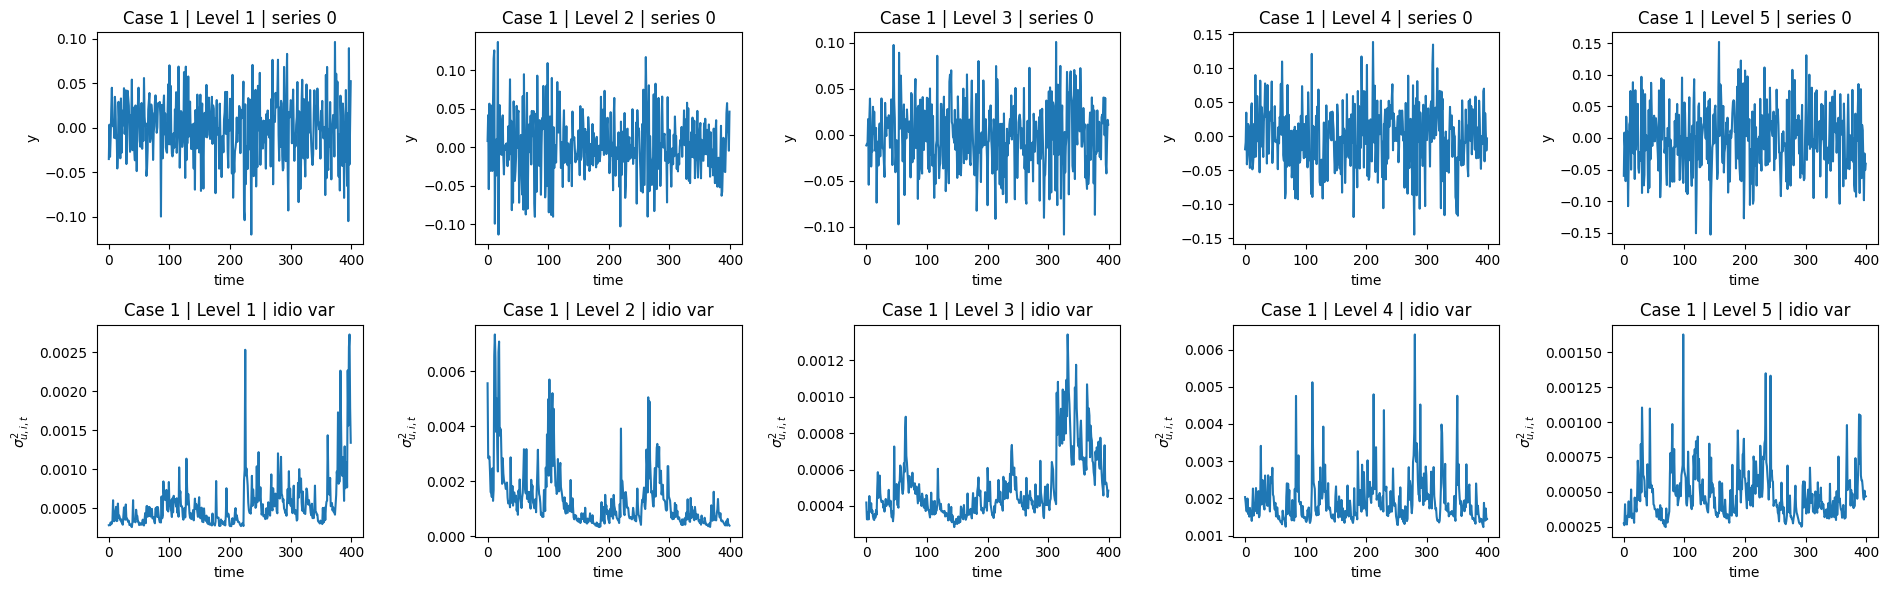

In [10]:
def plot_one_series_across_levels_case1(
    outputs: list[dict],
    series_id: int = 0,
    T_plot: int = 400,
    use_sigma2: bool = True,
):
    """
    Case 1 (GARCH) visualization in the SAME format as Case 2:
    - 2 x 5 grid (top: y, bottom: sigma2_idio)
    - consistent naming: series_id, time, y, sigma2_idio
    - reads from outputs[j]["csv_path"] like Case 2 code
    """
    n_levels = len(outputs)
    fig_rows = 2 if use_sigma2 else 1

    fig, axes = plt.subplots(
        fig_rows, n_levels,
        figsize=(3.8 * n_levels, 3.0 * fig_rows),
        sharex=False, sharey=False
    )
    if fig_rows == 1:
        axes = np.array([axes])  # make it 2D

    # Ensure left-to-right is level 1..5
    outs = sorted(outputs, key=lambda o: o["config"]["level"] if "config" in o else o.get("tag", ""))

    for j, out in enumerate(outs):
        # Robustly extract level for title
        level = out.get("config", {}).get("level", None)
        if level is None:
            # fallback: parse from tag if needed
            level = j + 1

        df = pd.read_csv(out["csv_path"])

        # Normalize column names if needed (some older dumps might have 'return'/'firm_id')
        if "firm_id" in df.columns and "series_id" not in df.columns:
            df = df.rename(columns={"firm_id": "series_id"})
        if "return" in df.columns and "y" not in df.columns:
            df = df.rename(columns={"return": "y"})

        s = df[df["series_id"] == series_id].sort_values("time").head(T_plot)
        if s.empty:
            raise ValueError(f"series_id={series_id} not found in {out.get('tag','(no tag)')}")

        # --- Plot returns y ---
        ax = axes[0, j]
        ax.plot(s["time"].values, s["y"].values)
        ax.set_title(f"Case 1 | Level {level} | series {series_id}")
        ax.set_xlabel("time")
        ax.set_ylabel("y")

        # --- Plot sigma2_idio (if available) ---
        if use_sigma2:
            ax2 = axes[1, j]
            if "sigma2_idio" in s.columns:
                ax2.plot(s["time"].values, s["sigma2_idio"].values)
                ax2.set_ylabel(r"$\sigma^2_{u,i,t}$")
            else:
                ax2.text(0.5, 0.5, "sigma2_idio not found", ha="center", va="center")
            ax2.set_title(f"Case 1 | Level {level} | idio var")
            ax2.set_xlabel("time")

    plt.tight_layout()
    plt.show()


# Example usage (Case 1 outputs list from your generator):
plot_one_series_across_levels_case1(outputs, series_id=0, T_plot=400, use_sigma2=True)


case 2

In [6]:
# =========================
# Case 2 (HAR) — 5-level dataset generation (FINAL CLEAN VERSION)
# =========================

import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import importlib
import ts_synth.simulators.har as ha
importlib.reload(ha)
from simulators.har import HARSimulator

# -------------------------
# Difficulty levels
# -------------------------
CASE2_LEVELS = [
    # Level 1 — baseline
    dict(level=1, s=0.60, lam=0.40, c_idio=2e-4, gamma=1.00, n_firms=50),
    # Level 2 — heavier tails
    dict(level=2, s=0.90, lam=0.40, c_idio=2e-4, gamma=1.00, n_firms=50),
    # Level 3 — stronger temporal dependence
    dict(level=3, s=0.60, lam=0.70, c_idio=2e-4, gamma=1.00, n_firms=50),
    # Level 4 — higher idiosyncratic noise floor
    dict(level=4, s=0.60, lam=0.40, c_idio=1e-3, gamma=1.00, n_firms=50),
    # Level 5 — stronger cross-sectional interaction
    dict(level=5, s=0.60, lam=0.40, c_idio=2e-4, gamma=4.00, n_firms=50),
]

# Fixed parameters
CASE2_FIXED = dict(
    T=20000,
    n_factors=3,
)

# Optional trimming for comparability with Case 1
CASE2_POST_BURN_IN = 200  # set 0 to disable


# -------------------------
# Helper functions
# -------------------------

def har_coeffs_from_s_lambda(s: float, lam: float) -> tuple[float, float, float]:
    """
    Map total feedback s and long-memory share lam into HAR coefficients.
    Ensures b1 + b5 + b22 = s, b22 = lam*s, b1 = b5 = (1-lam)*s/2.
    """
    if not (0.0 <= lam <= 1.0):
        raise ValueError(f"lam must be in [0,1], got {lam}")
    if not (0.0 <= s < 1.0):
        raise ValueError(f"s must be in [0,1), got {s}")
    b22 = lam * s
    rem = (1.0 - lam) * s
    b1 = rem / 2.0
    b5 = rem / 2.0
    return float(b1), float(b5), float(b22)


def _safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    if a.size < 2 or b.size < 2:
        return float("nan")
    if np.std(a) == 0.0 or np.std(b) == 0.0:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])


# -------------------------
# Dataset generator
# -------------------------

def generate_case2_dataset(
    level_cfg: dict,
    fixed_cfg: dict,
    seed: int,
    out_dir: str | Path,
    save_csv: bool = True,
    save_parquet: bool = False,
    post_burn_in: int = 0,
) -> dict:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Merge configs
    cfg = {}
    cfg.update(fixed_cfg)
    cfg.update(level_cfg)

    # Stability check
    if cfg["s"] >= 1.0:
        raise ValueError(f"Unstable HAR recursion: s must be < 1, got {cfg['s']}")

    # HAR coefficients
    b1, b5, b22 = har_coeffs_from_s_lambda(cfg["s"], cfg["lam"])
    c_factor = cfg["gamma"] * cfg["c_idio"]

    # Construct simulator
    sim = HARSimulator(
        T=cfg["T"],
        n_firms=cfg["n_firms"],
        n_factors=cfg["n_factors"],
        b1_u=b1,
        b5_u=b5,
        b22_u=b22,
        c_idio=cfg["c_idio"],
        c_factor=c_factor,
        b1_f=b1,
        b5_f=b5,
        b22_f=b22,
        seed=seed,
    )

    result = sim.simulate()
    df = sim.to_dataframe()

    # Normalize column names
    df = df.rename(columns={"firm_id": "series_id", "return": "y"})

    # Metadata columns
    df["case"] = 2
    df["difficulty_level"] = int(cfg["level"])

    # Optional trimming
    if post_burn_in and post_burn_in > 0:
        df = df[df["time"] >= post_burn_in].copy()
        df["time"] -= post_burn_in

    # Save
    tag = (
        f"case2_har_level{cfg['level']:02d}"
        f"_N{cfg['n_firms']}_T{cfg['T']}"
        f"_s{cfg['s']:.2f}_lam{cfg['lam']:.2f}"
        f"_cu{cfg['c_idio']:.0e}_gamma{cfg['gamma']:.2f}"
        f"_seed{seed}"
    )

    csv_path = out_dir / f"{tag}.csv"
    pq_path = out_dir / f"{tag}.parquet"
    meta_path = out_dir / f"{tag}.meta.json"

    if save_csv:
        df.to_csv(csv_path, index=False)
    if save_parquet:
        df.to_parquet(pq_path, index=False)

    # Save metadata
    meta = {
        "case": "case2_har",
        "tag": tag,
        "seed": seed,
        "tuned_params": {
            "s": cfg["s"],
            "lam": cfg["lam"],
            "b1": b1,
            "b5": b5,
            "b22": b22,
            "c_idio": cfg["c_idio"],
            "c_factor": c_factor,
            "gamma": cfg["gamma"],
            "n_firms": cfg["n_firms"],
        },
        "fixed_params": fixed_cfg,
        "post_burn_in": int(post_burn_in),
        "sim_params_dump": result.get("params", {}),
    }

    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    # Quick diagnostics
    df_sorted = df.sort_values(["series_id", "time"]).copy()
    df_sorted["abs_y"] = df_sorted["y"].abs()
    df_sorted["abs_y_lag1"] = df_sorted.groupby("series_id")["abs_y"].shift(1)

    vol_cluster = (
        df_sorted.dropna(subset=["abs_y_lag1"])
        .groupby("series_id")
        .apply(lambda g: _safe_corr(g["abs_y"].to_numpy(), g["abs_y_lag1"].to_numpy()))
    )

    def _lag_corr_abs(g, lag):
        x = g["abs_y"].to_numpy()
        if x.size <= lag + 1:
            return float("nan")
        return _safe_corr(x[lag:], x[:-lag])

    ac5 = df_sorted.groupby("series_id").apply(lambda g: _lag_corr_abs(g, 5))
    ac22 = df_sorted.groupby("series_id").apply(lambda g: _lag_corr_abs(g, 22))

    summary = {
        "n_rows": int(df.shape[0]),
        "n_series": int(df["series_id"].nunique()),
        "T_effective": int(df["time"].nunique()),
        "mean_return": float(df["y"].mean()),
        "std_return": float(df["y"].std()),
        "mean_sigma2_idio": float(df["sigma2_idio"].mean()),
        "vol_clustering_corr_abs_lag1_mean": float(np.nanmean(vol_cluster.to_numpy())),
        "abs_return_autocorr_lag5_mean": float(np.nanmean(ac5.to_numpy())),
        "abs_return_autocorr_lag22_mean": float(np.nanmean(ac22.to_numpy())),
    }

    return {
        "tag": tag,
        "csv_path": str(csv_path) if save_csv else None,
        "parquet_path": str(pq_path) if save_parquet else None,
        "meta_path": str(meta_path),
        "config": cfg,
        "summary": summary,
    }


def generate_case2_5levels(
    out_dir: str | Path,
    base_seed: int = 123,
    save_csv: bool = True,
    save_parquet: bool = False,
    post_burn_in: int = 0,
) -> list[dict]:
    outputs = []
    for level_cfg in CASE2_LEVELS:
        seed = base_seed + int(level_cfg["level"])
        out = generate_case2_dataset(
            level_cfg=level_cfg,
            fixed_cfg=CASE2_FIXED,
            seed=seed,
            out_dir=out_dir,
            save_csv=save_csv,
            save_parquet=save_parquet,
            post_burn_in=post_burn_in,
        )
        outputs.append(out)
    return outputs


In [7]:
# -------------------------
# Run generation
# -------------------------
OUT_DIR = "./generated_datasets_T20000/case2_har_5levels"
outputs = generate_case2_5levels(out_dir=OUT_DIR, base_seed=2025, save_csv=True, save_parquet=False)

pd.DataFrame([{"tag": o["tag"], **o["summary"]} for o in outputs])

C:\Users\Sun Jiaze\AppData\Local\Temp\ipykernel_20724\3281750004.py:179: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _safe_corr(g["abs_y"].to_numpy(), g["abs_y_lag1"].to_numpy()))
C:\Users\Sun Jiaze\AppData\Local\Temp\ipykernel_20724\3281750004.py:188: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ac5 = df_sorted.groupby("series_id").apply(lambda g: _lag_corr_abs(g, 5))
C:\Users\Sun Jiaze\AppData\L

,tag,n_rows,n_series,T_effective,mean_return,std_return,mean_sigma2_idio,vol_clustering_corr_abs_lag1_mean,abs_return_autocorr_lag5_mean,abs_return_autocorr_lag22_mean
0,case2_har_level01_N50_T20000_s0.60_lam0.40_cu2...,1000000,50,20000,0.000020,0.031036,0.000500,0.108297,0.049987,0.019933
1,case2_har_level02_N50_T20000_s0.90_lam0.40_cu2...,1000000,50,20000,0.000057,0.061332,0.002141,0.292955,0.214837,0.154403
2,case2_har_level03_N50_T20000_s0.60_lam0.70_cu2...,1000000,50,20000,-0.000081,0.030056,0.000500,0.060960,0.033940,0.021739
3,case2_har_level04_N50_T20000_s0.60_lam0.40_cu1...,1000000,50,20000,0.000337,0.067884,0.002500,0.102883,0.046855,0.018590
4,case2_har_level05_N50_T20000_s0.60_lam0.40_cu2...,1000000,50,20000,0.000060,0.045685,0.000498,0.083197,0.032523,0.013552


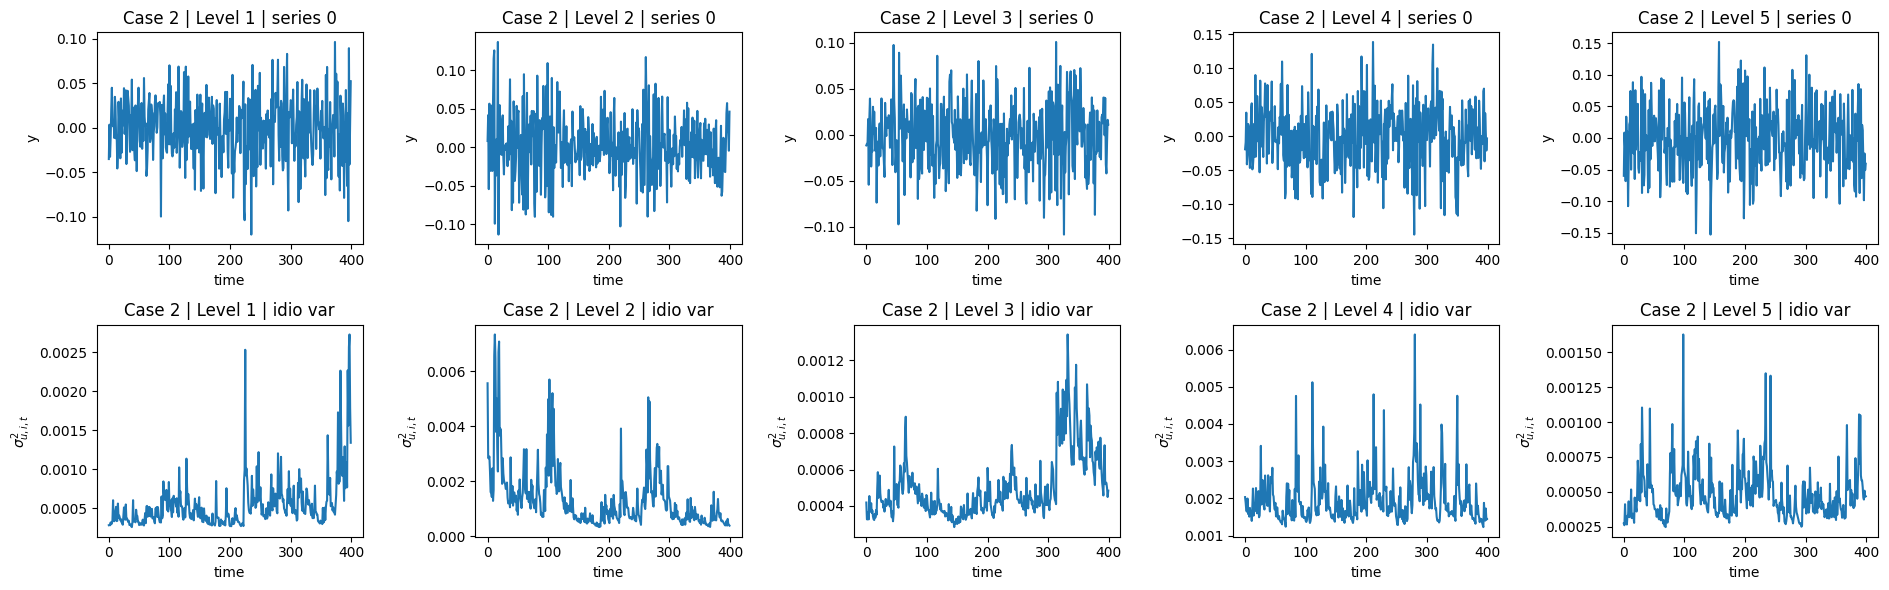

In [11]:
def plot_one_series_across_levels_case2(
    outputs: list[dict],
    series_id: int = 0,
    T_plot: int = 400,
    use_sigma2: bool = True,
):
    """
    Case 2 (HAR) visualization.
    - 2 x 5 grid
    - Top row: returns y_t
    - Bottom row: sigma2_idio_t (if available)
    """
    n_levels = len(outputs)
    fig_rows = 2 if use_sigma2 else 1

    fig, axes = plt.subplots(
        fig_rows, n_levels,
        figsize=(3.8 * n_levels, 3.0 * fig_rows),
        sharex=False,
        sharey=False,
    )

    if fig_rows == 1:
        axes = np.array([axes])  # ensure 2D indexing

    # sort left → right by difficulty level
    outs = sorted(outputs, key=lambda x: x["config"]["level"])

    for j, out in enumerate(outs):
        level = out["config"]["level"]
        df = pd.read_csv(out["csv_path"])

        # Normalize column names defensively
        if "firm_id" in df.columns and "series_id" not in df.columns:
            df = df.rename(columns={"firm_id": "series_id"})
        if "return" in df.columns and "y" not in df.columns:
            df = df.rename(columns={"return": "y"})

        s = (
            df[df["series_id"] == series_id]
            .sort_values("time")
            .head(T_plot)
        )

        if s.empty:
            raise ValueError(f"series_id={series_id} not found in level {level}")

        # ---- returns ----
        ax = axes[0, j]
        ax.plot(s["time"].values, s["y"].values)
        ax.set_title(f"Case 2 | Level {level} | series {series_id}")
        ax.set_xlabel("time")
        ax.set_ylabel("y")

        # ---- idiosyncratic variance ----
        if use_sigma2:
            ax2 = axes[1, j]
            if "sigma2_idio" in s.columns:
                ax2.plot(s["time"].values, s["sigma2_idio"].values)
                ax2.set_ylabel(r"$\sigma^2_{u,i,t}$")
            else:
                ax2.text(
                    0.5, 0.5,
                    "sigma2_idio not found",
                    ha="center",
                    va="center",
                )
            ax2.set_title(f"Case 2 | Level {level} | idio var")
            ax2.set_xlabel("time")

    plt.tight_layout()
    plt.show()


# Example usage
plot_one_series_across_levels_case2(outputs, series_id=0, T_plot=400, use_sigma2=True)


case 3

In [12]:
# =========================
# Case 3: Heavy tails + outliers (5 difficulty levels)
# =========================

import os
import json
from pathlib import Path
import numpy as np
import pandas as pd

import importlib
import simulators.heavy_tail as ht
importlib.reload(ht)
from simulators.heavy_tail import HeavyTailSimulator

In [13]:
CASE3_LEVELS = [
    # Level 1 — baseline: moderately heavy tails, no outliers
    dict(level=1, nu=8,  pi_outlier=0.00, outlier_scale=6,  rho_v=0.90, n_firms=50),
    # Level 2 — heavier tails only (distributional misspecification without contamination)
    dict(level=2, nu=3,  pi_outlier=0.00, outlier_scale=6,  rho_v=0.90, n_firms=50),
    # Level 3 — outlier frequency only (rare shocks become more frequent)
    dict(level=3, nu=8,  pi_outlier=0.02, outlier_scale=6,  rho_v=0.90, n_firms=50),
    # Level 4 — outlier magnitude only (same rarity, larger shocks)
    dict(level=4, nu=8,  pi_outlier=0.005, outlier_scale=12, rho_v=0.90, n_firms=50),
    # Level 5 — combined stress: heavy tails + frequent + large outliers
    dict(level=5, nu=3,  pi_outlier=0.02, outlier_scale=12, rho_v=0.90, n_firms=50),
]

CASE3_FIXED = dict(
    T=20000,
    n_factors=3,
    sigma2_bar_factor=0.02,
    sigma2_bar_idio=0.04,
    burn_in=200,
)

def normalize_tidy_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename_map = {}
    if "firm_id" in df.columns and "series_id" not in df.columns:
        rename_map["firm_id"] = "series_id"
    if "return" in df.columns and "y" not in df.columns:
        rename_map["return"] = "y"
    if rename_map:
        df = df.rename(columns=rename_map)

    required = {"time", "series_id", "y"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Missing required columns {missing}. Found {list(df.columns)}")
    return df

def safe_vol_cluster_corr_abs_lag1(df: pd.DataFrame) -> float:
    d = df.sort_values(["series_id", "time"]).copy()
    d["abs_y"] = d["y"].abs()
    d["abs_y_lag1"] = d.groupby("series_id")["abs_y"].shift(1)

    vals = []
    for _, g in d.dropna(subset=["abs_y_lag1"]).groupby("series_id"):
        x = g["abs_y"].to_numpy()
        y = g["abs_y_lag1"].to_numpy()
        if x.size < 10:
            continue
        if np.std(x) == 0 or np.std(y) == 0:
            continue
        c = np.corrcoef(x, y)[0, 1]
        if np.isfinite(c):
            vals.append(c)
    return float(np.mean(vals)) if vals else float("nan")

def generate_case3_dataset(
    level_cfg: dict,
    fixed_cfg: dict,
    seed: int,
    out_dir: str | Path,
    save_csv: bool = True,
    save_parquet: bool = False,
) -> dict:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    cfg = {**fixed_cfg, **level_cfg}

    sim = HeavyTailSimulator(
        T=cfg["T"],
        n_firms=cfg["n_firms"],
        n_factors=cfg["n_factors"],
        rho_v=cfg["rho_v"],
        sigma2_bar_factor=cfg["sigma2_bar_factor"],
        sigma2_bar_idio=cfg["sigma2_bar_idio"],
        nu=cfg["nu"],
        pi_outlier=cfg["pi_outlier"],
        outlier_scale=cfg["outlier_scale"],
        burn_in=cfg["burn_in"],
        seed=seed,
    )

    result = sim.simulate()
    df = normalize_tidy_columns(sim.to_dataframe())

    tag = (
        f"case3_heavytail_level{cfg['level']:02d}"
        f"_N{cfg['n_firms']}_T{cfg['T']}_seed{seed}"
        f"_nu{cfg['nu']}_p{cfg['pi_outlier']:.4f}_os{cfg['outlier_scale']}"
        f"_rho{cfg['rho_v']:.2f}"
    )

    csv_path = out_dir / f"{tag}.csv"
    pq_path = out_dir / f"{tag}.parquet"
    meta_path = out_dir / f"{tag}.meta.json"

    if save_csv:
        df.to_csv(csv_path, index=False)
    if save_parquet:
        df.to_parquet(pq_path, index=False)

    meta = {
        "case": "case3_heavy_tails_outliers",
        "tag": tag,
        "seed": seed,
        "tuned_params": {
            "nu": cfg["nu"],
            "pi_outlier": cfg["pi_outlier"],
            "outlier_scale": cfg["outlier_scale"],
            "rho_v": cfg["rho_v"],
            "n_firms": cfg["n_firms"],
        },
        "fixed_params": dict(fixed_cfg),
        "sim_params_dump": result.get("params", {}),
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    outlier_rate_emp = float(df["is_outlier"].mean()) if "is_outlier" in df.columns else float("nan")
    mean_sigma2 = float(df["sigma2_idio"].mean()) if "sigma2_idio" in df.columns else float("nan")

    summary = {
        "n_rows": int(df.shape[0]),
        "n_series": int(df["series_id"].nunique()),
        "T_effective": int(df["time"].nunique()),
        "mean_return": float(df["y"].mean()),
        "std_return": float(df["y"].std()),
        "mean_sigma2_idio": mean_sigma2,
        "emp_outlier_rate": outlier_rate_emp,
        "vol_clustering_corr_abs_lag1_mean": safe_vol_cluster_corr_abs_lag1(df),
    }

    return {
        "tag": tag,
        "csv_path": str(csv_path) if save_csv else None,
        "parquet_path": str(pq_path) if save_parquet else None,
        "meta_path": str(meta_path),
        "config": cfg,
        "summary": summary,
    }

def generate_case3_5levels(
    out_dir: str | Path,
    base_seed: int = 2025,
    save_csv: bool = True,
    save_parquet: bool = False,
) -> list[dict]:
    outputs = []
    for level_cfg in CASE3_LEVELS:
        level = int(level_cfg["level"])
        seed = base_seed + level
        outputs.append(
            generate_case3_dataset(
                level_cfg=level_cfg,
                fixed_cfg=CASE3_FIXED,
                seed=seed,
                out_dir=out_dir,
                save_csv=save_csv,
                save_parquet=save_parquet,
            )
        )
    return outputs


In [14]:
# -------------------------
# RUN GENERATION
# -------------------------
OUT_DIR = "./generated_datasets_T20000/case3_heavytail_5levels"
outputs_case3 = generate_case3_5levels(out_dir=OUT_DIR, base_seed=2025, save_csv=True, save_parquet=False)

pd.DataFrame([{"tag": o["tag"], **o["summary"]} for o in outputs_case3])

,tag,n_rows,n_series,T_effective,mean_return,std_return,mean_sigma2_idio,emp_outlier_rate,vol_clustering_corr_abs_lag1_mean
0,case3_heavytail_level01_N50_T20000_seed2026_nu...,1000000,50,20000,0.000590,0.240792,0.040031,0.000000,0.070797
1,case3_heavytail_level02_N50_T20000_seed2027_nu...,1000000,50,20000,-0.001091,0.240933,0.040471,0.000000,0.128650
2,case3_heavytail_level03_N50_T20000_seed2028_nu...,1000000,50,20000,-0.000130,0.291277,0.040065,0.019965,0.045224
3,case3_heavytail_level04_N50_T20000_seed2029_nu...,1000000,50,20000,-0.001179,0.291833,0.039923,0.004973,0.037435
4,case3_heavytail_level05_N50_T20000_seed2030_nu...,1000000,50,20000,0.001984,0.416125,0.039323,0.020082,0.050051


In [15]:
def plot_case3_one_series_across_levels(
    outputs: list[dict],
    series_id: int = 0,
    T_plot: int = 400,
):
    """
    Case 3 visualization (Heavy tails + outliers).

    Layout: 2 x 5 grid
      - Row 1: returns y_t
      - Row 2: sigma^2_{u,i,t}
      - Columns: difficulty levels 1..5

    Parameters
    ----------
    outputs : list of dict
        Output list returned by generate_case3_5levels()
    series_id : int
        Which series to plot (exists across all levels by construction)
    T_plot : int
        Number of initial time steps to plot
    """

    outputs_sorted = sorted(outputs, key=lambda x: x["config"]["level"])
    n_levels = len(outputs_sorted)

    fig, axes = plt.subplots(
        2, n_levels,
        figsize=(3.8 * n_levels, 6.0),
        sharex=False,
        sharey=False,
    )

    for j, out in enumerate(outputs_sorted):
        level = out["config"]["level"]
        df = pd.read_csv(out["csv_path"])

        s = (
            df[df["series_id"] == series_id]
            .sort_values("time")
            .head(T_plot)
        )

        if s.empty:
            raise ValueError(f"series_id={series_id} not found in Level {level}")

        # -------------------
        # Top row: returns
        # -------------------
        ax_y = axes[0, j]
        ax_y.plot(s["time"], s["y"], linewidth=1.0)
        ax_y.set_title(f"Case 3 – Level {level}", fontsize=11)
        ax_y.set_xlabel("time")
        ax_y.set_ylabel("y")

        # Mark outliers (if present)
        if "is_outlier" in s.columns:
            out_idx = s["is_outlier"].values
            ax_y.scatter(
                s.loc[out_idx, "time"],
                s.loc[out_idx, "y"],
                color="red",
                s=8,
                alpha=0.6,
                label="outlier" if j == 0 else None,
            )

        # -------------------
        # Bottom row: variance
        # -------------------
        ax_v = axes[1, j]
        if "sigma2_idio" in s.columns:
            ax_v.plot(s["time"], s["sigma2_idio"], linewidth=1.0)
            ax_v.set_ylabel(r"$\sigma^2_{u,i,t}$")
        else:
            ax_v.text(
                0.5, 0.5, "sigma2_idio not available",
                ha="center", va="center", transform=ax_v.transAxes
            )

        ax_v.set_xlabel("time")

    # Global adjustments
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")

    fig.suptitle(
        f"Case 3: Heavy Tails + Outliers (series_id = {series_id})",
        fontsize=14,
        y=1.02,
    )

    plt.tight_layout()
    plt.show()


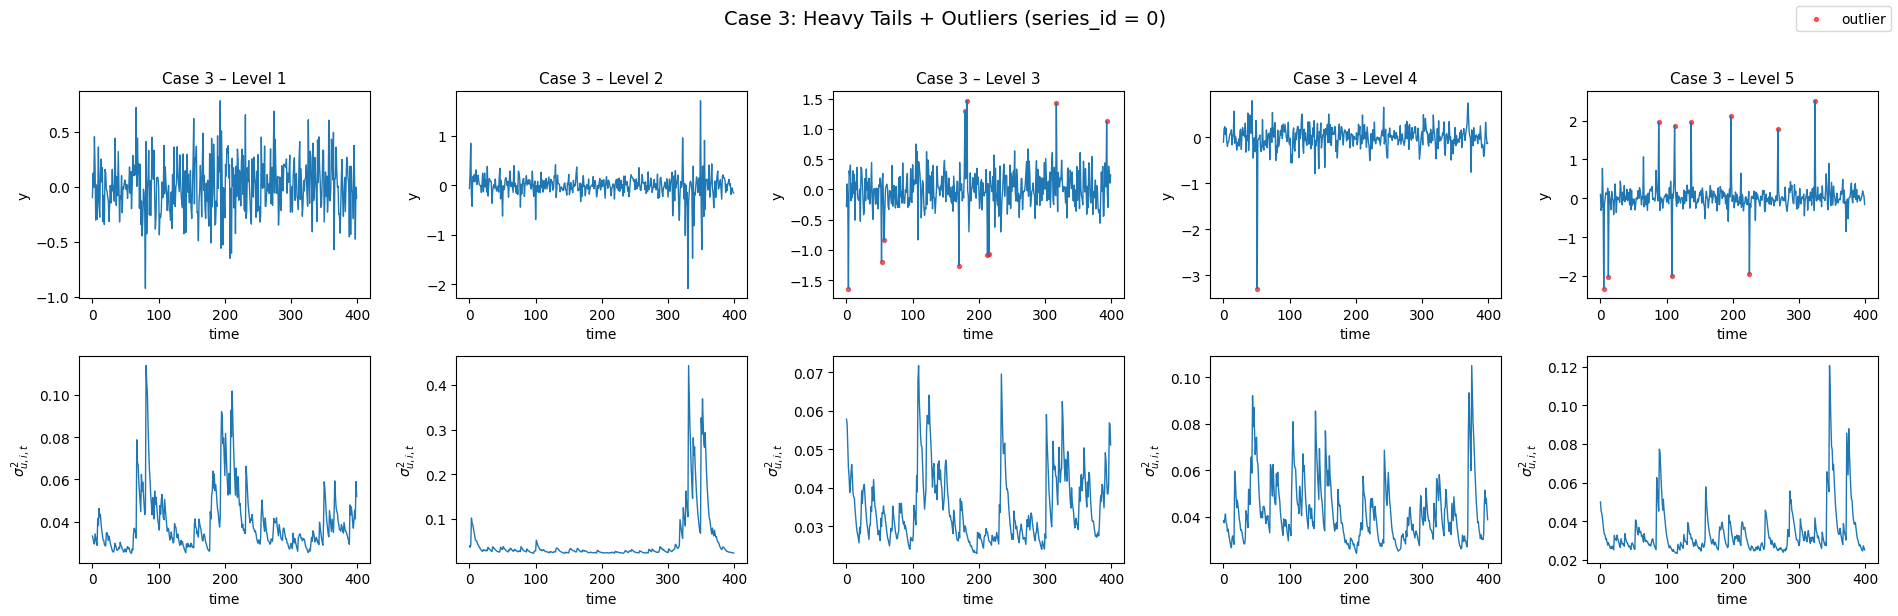

In [16]:
plot_case3_one_series_across_levels(
    outputs=outputs_case3,
    series_id=0,
    T_plot=400,
)

case 4


In [17]:
# =========================
# Case 4 (Option B): Market-wide Regime Switching Panel — 5-level dataset generation
# FULL corrected code (ready to run)
# =========================

import json
from pathlib import Path
import numpy as np
import pandas as pd
import importlib

import simulators.regime_switching as rs
importlib.reload(rs)
from simulators.regime_switching import MarketRegimePanelSimulator

CASE4_LEVELS = [
    # (1) Baseline: moderate blocks + moderate separation + moderate AR memory
    dict(
        level=1,
        block_size=50,
        mu_U=0.0012, mu_S=0.0, mu_D=-0.0012,
        sigma_U=0.010, sigma_S=0.0085, sigma_D=0.016,
        phi=0.20,
    ),

    # (2) Frequent breaks: fast switching, same-ish separation
    dict(
        level=2,
        block_size=10,
        mu_U=0.0012, mu_S=0.0, mu_D=-0.0012,
        sigma_U=0.010, sigma_S=0.0085, sigma_D=0.016,
        phi=0.20,
    ),

    # (3) Subtle regimes: regimes are weakly separated (harder to infer), moderate breaks
    dict(
        level=3,
        block_size=50,
        mu_U=0.0005, mu_S=0.0, mu_D=-0.0005,
        sigma_U=0.010, sigma_S=0.0095, sigma_D=0.011,
        phi=0.20,
    ),

    # (4) Strong regimes: big mean/vol gaps (should be very detectable), moderate breaks
    dict(
        level=4,
        block_size=50,
        mu_U=0.0020, mu_S=0.0, mu_D=-0.0020,
        sigma_U=0.008, sigma_S=0.0075, sigma_D=0.020,
        phi=0.20,
    ),

    # (5) High memory within regimes: same separation as baseline but high phi
    dict(
        level=5,
        block_size=50,
        mu_U=0.0012, mu_S=0.0, mu_D=-0.0012,
        sigma_U=0.010, sigma_S=0.0085, sigma_D=0.016,
        phi=0.60,
    ),
]


# -------------------------------------------------------
# Fixed parameters (constant across levels)
# -------------------------------------------------------
CASE4_FIXED = dict(
    T=20000,
    n_firms=50,           # <-- Option B: panel size; set once for the paper, or vary if you decide later
    n_factors=None,        # unused here; kept for symmetry if you have wrappers
    Pi_block=None,         # use simulator default persistent transition matrix
    burn_in=200,
    # mild cross-sectional heterogeneity; set to 0.0 if you want identical series conditional on regime
    mu_scale_logsigma=0.10,
    sig_scale_logsigma=0.10,
)


# -------------------------------------------------------
# Utilities
# -------------------------------------------------------
def json_safe(v):
    """Make values JSON serializable."""
    if isinstance(v, np.ndarray):
        return v.tolist()
    if isinstance(v, (np.integer, np.floating)):
        return v.item()
    return v


def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    """Correlation with basic safeguards."""
    if a.size < 3 or b.size < 3:
        return float("nan")
    sa = float(np.std(a))
    sb = float(np.std(b))
    if sa == 0.0 or sb == 0.0:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])


# -------------------------------------------------------
# Dataset generator
# -------------------------------------------------------
def generate_case4_dataset(
    level_cfg: dict,
    fixed_cfg: dict,
    seed: int,
    out_dir: str | Path,
    save_csv: bool = True,
    save_parquet: bool = False,
) -> dict:
    """
    Generate one Case 4 dataset (market-wide regime panel) and save artifacts.

    Output DF schema (tidy long):
      time, series_id, y, regime, regime_label
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    cfg = {**fixed_cfg, **level_cfg}

    # ---- construct simulator (Option B: shared regime across firms) ----
    sim = MarketRegimePanelSimulator(
        T=cfg["T"],
        n_firms=cfg["n_firms"],
        block_size=cfg["block_size"],
        mu_U=cfg["mu_U"],
        mu_S=cfg["mu_S"],
        mu_D=cfg["mu_D"],
        sigma_U=cfg["sigma_U"],
        sigma_S=cfg["sigma_S"],
        sigma_D=cfg["sigma_D"],
        phi=cfg["phi"],
        Pi_block=cfg["Pi_block"],
        mu_scale_logsigma=cfg["mu_scale_logsigma"],
        sig_scale_logsigma=cfg["sig_scale_logsigma"],
        burn_in=cfg["burn_in"],
        seed=seed,
    )

    result = sim.simulate()
    df = sim.to_dataframe()  # already tidy long in the updated simulator

    # Add identifiers
    df["case"] = 4
    df["difficulty_level"] = int(cfg["level"])

    # ---- save artifacts ----
    tag = (
        f"case4_marketregime_level{cfg['level']:02d}"
        f"_N{cfg['n_firms']}_T{cfg['T']}"
        f"_block{cfg['block_size']}_seed{seed}"
    )

    csv_path = out_dir / f"{tag}.csv"
    pq_path = out_dir / f"{tag}.parquet"
    meta_path = out_dir / f"{tag}.meta.json"

    if save_csv:
        df.to_csv(csv_path, index=False)
    if save_parquet:
        df.to_parquet(pq_path, index=False)

    # ---- metadata ----
    meta = {
        "case": "case4_market_regime_panel",
        "tag": tag,
        "seed": seed,
        "tuned_params": {
            "block_size": cfg["block_size"],
            "mu": [cfg["mu_U"], cfg["mu_S"], cfg["mu_D"]],
            "sigma": [cfg["sigma_U"], cfg["sigma_S"], cfg["sigma_D"]],
            "phi": cfg["phi"],
        },
        "fixed_params": {k: json_safe(v) for k, v in fixed_cfg.items()},
        "sim_params_dump": {k: json_safe(v) for k, v in result.get("params", {}).items()},
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    # ---- quick diagnostics (market-wide regime switch rate + within-regime mean separation) ----
    # Regime switch rate computed on the shared regime path (use result["states"])
    states = np.asarray(result["states"], dtype=int)
    switch_rate = float(np.mean(states[1:] != states[:-1])) if states.size > 1 else float("nan")

    # Mean return per regime (averaged over firms & time)
    regime_means = (
        df.groupby("regime")["y"].mean().sort_index().to_dict()
        if "regime" in df.columns else {}
    )

    # Cross-firm average correlation (cheap proxy): corr of firm 0 vs firm 1 (if N>=2)
    # Use wide view for just first two firms
    if cfg["n_firms"] >= 2:
        wide01 = df[df["series_id"].isin([0, 1])].pivot(index="time", columns="series_id", values="y")
        corr01 = safe_corr(wide01[0].to_numpy(), wide01[1].to_numpy()) if wide01.shape[0] > 10 else float("nan")
    else:
        corr01 = float("nan")

    summary = {
        "n_rows": int(df.shape[0]),
        "n_series": int(df["series_id"].nunique()),
        "T_effective": int(df["time"].nunique()),
        "mean_y": float(df["y"].mean()),
        "std_y": float(df["y"].std()),
        "regime_switch_rate": switch_rate,
        "mean_y_by_regime": regime_means,
        "corr_firm0_firm1": corr01,
    }

    return {
        "tag": tag,
        "csv_path": str(csv_path) if save_csv else None,
        "parquet_path": str(pq_path) if save_parquet else None,
        "meta_path": str(meta_path),
        "config": cfg,
        "summary": summary,
    }


# -------------------------------------------------------
# 5-level batch generator
# -------------------------------------------------------
def generate_case4_5levels(
    out_dir: str | Path,
    base_seed: int = 2025,
    save_csv: bool = True,
    save_parquet: bool = False,
) -> list[dict]:
    outputs = []
    for level_cfg in CASE4_LEVELS:
        seed = int(base_seed + int(level_cfg["level"]))
        outputs.append(
            generate_case4_dataset(
                level_cfg=level_cfg,
                fixed_cfg=CASE4_FIXED,
                seed=seed,
                out_dir=out_dir,
                save_csv=save_csv,
                save_parquet=save_parquet,
            )
        )
    return outputs

In [18]:
# =========================
# RUN GENERATION (Case 4)
# =========================

OUT_DIR = "./generated_datasets_T20000/case4_regime_5levels"
outputs = generate_case4_5levels(out_dir=OUT_DIR, base_seed=42, save_csv=True)

# Quick table
pd.DataFrame([{"tag": o["tag"], **o["summary"]} for o in outputs])


,tag,n_rows,n_series,T_effective,mean_y,std_y,regime_switch_rate,mean_y_by_regime,corr_firm0_firm1
0,case4_marketregime_level01_N50_T20000_block50_...,1000000,50,20000,3.768917e-04,0.011758,0.002050,"{0: 0.001472735205700435, 1: -9.06815767968777...",0.020670
1,case4_marketregime_level02_N50_T20000_block10_...,1000000,50,20000,1.109423e-04,0.012294,0.010451,"{0: 0.0015394467204719888, 1: 3.63602753808911...",0.019030
2,case4_marketregime_level03_N50_T20000_block50_...,1000000,50,20000,5.492596e-05,0.010198,0.002150,"{0: 0.0006217523494796744, 1: 1.42624084635889...",0.018015
3,case4_marketregime_level04_N50_T20000_block50_...,1000000,50,20000,7.339620e-04,0.011982,0.002250,"{0: 0.002481167368579379, 1: 1.110392417535757...",0.015612
4,case4_marketregime_level05_N50_T20000_block50_...,1000000,50,20000,4.788341e-07,0.016076,0.001750,"{0: 0.002895301520594042, 1: -1.79205160362694...",0.021008


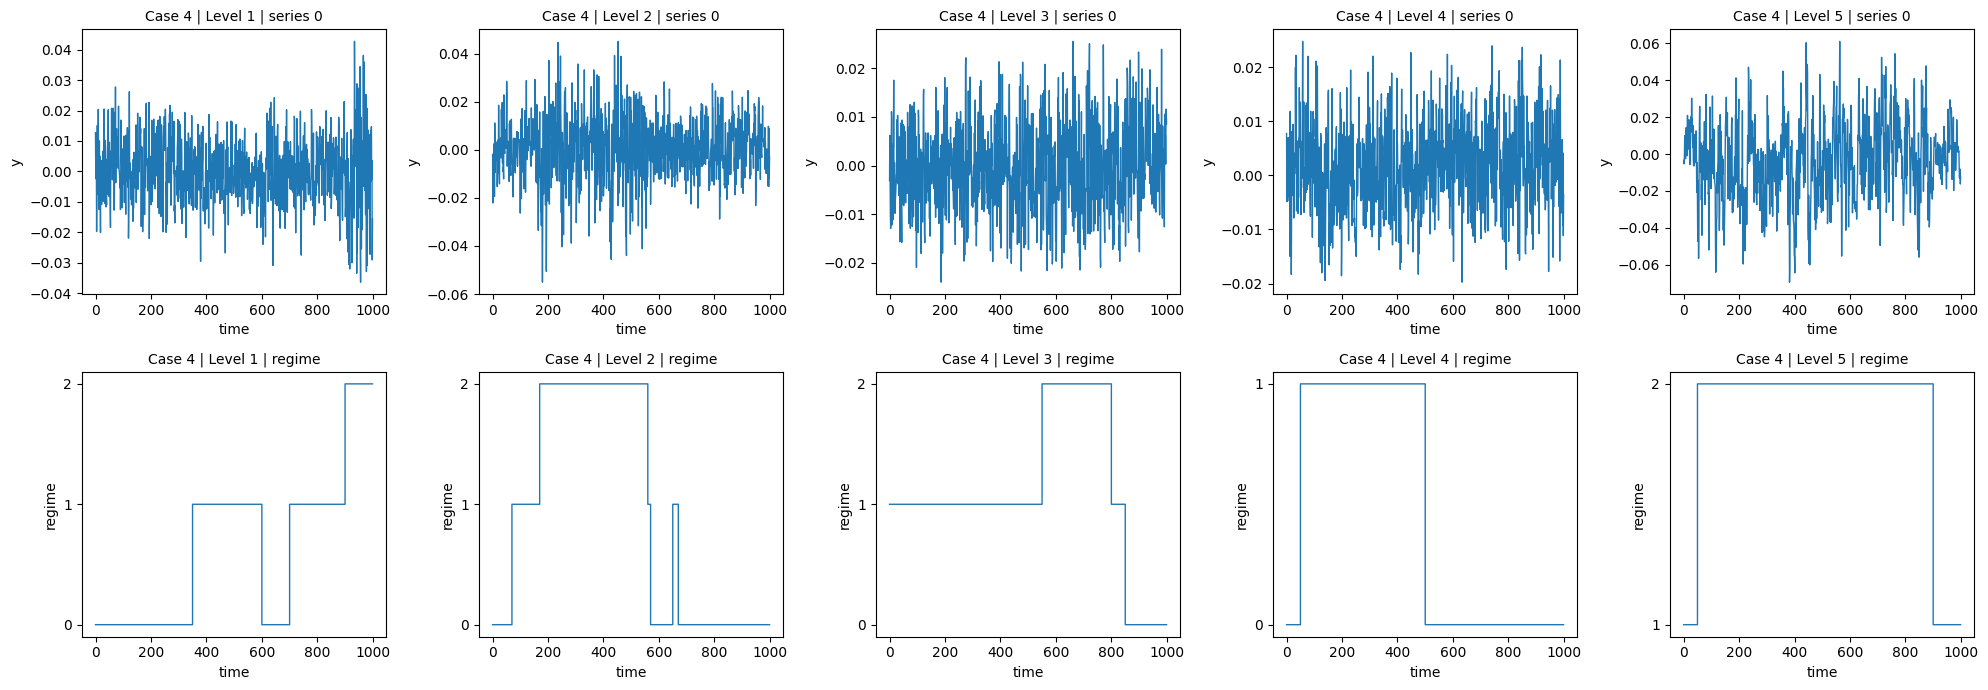

In [19]:
def plot_case4_one_series_across_levels(
    outputs: list[dict],
    series_id: int = 0,
    T_plot: int | None = 400,
    show_regime: bool = True,
    figsize: tuple[float, float] = (20, 7),
):
    if len(outputs) < 5:
        raise ValueError("Need at least 5 outputs (levels).")

    # sort outputs by level if available
    def _level_key(o):
        if "config" in o and isinstance(o["config"], dict) and "level" in o["config"]:
            return int(o["config"]["level"])
        # fallback: parse "...levelXX..." from tag
        tag = str(o.get("tag", ""))
        import re
        m = re.search(r"level(\d+)", tag)
        return int(m.group(1)) if m else 999

    outs = sorted(outputs, key=_level_key)[:5]

    nrows = 2 if show_regime else 1
    fig, axes = plt.subplots(nrows, 5, figsize=figsize, sharex=False)

    # normalize axes indexing
    if nrows == 1:
        axes = np.array([axes])  # shape (1, 5)

    for col, out in enumerate(outs):
        cfg = out.get("config", {})
        lvl = int(cfg.get("level", col + 1))

        # load df: prefer in-memory df if you stored it, else read csv_path
        if "df" in out and isinstance(out["df"], pd.DataFrame):
            df = out["df"].copy()
        else:
            csv_path = out.get("csv_path", None)
            if csv_path is None:
                raise KeyError(f"Output for level {lvl} missing 'csv_path' (or 'df').")
            df = pd.read_csv(csv_path)

        # normalize columns
        if "return" in df.columns and "y" not in df.columns:
            df = df.rename(columns={"return": "y"})
        if "firm_id" in df.columns and "series_id" not in df.columns:
            df = df.rename(columns={"firm_id": "series_id"})

        if "y" not in df.columns or "time" not in df.columns or "series_id" not in df.columns:
            raise KeyError(
                f"Case 4 df must contain columns time, series_id, y. Got: {list(df.columns)}"
            )

        # select series
        dsi = df[df["series_id"] == series_id].copy()
        if dsi.empty:
            sid0 = int(df["series_id"].min())
            dsi = df[df["series_id"] == sid0].copy()
            sid_used = sid0
        else:
            sid_used = series_id

        dsi = dsi.sort_values("time")

        # trim
        if T_plot is not None:
            dsi = dsi[dsi["time"] < int(T_plot)]

        # top: y
        ax1 = axes[0, col]
        ax1.plot(dsi["time"].to_numpy(), dsi["y"].to_numpy(), linewidth=1.0)
        ax1.set_title(f"Case 4 | Level {lvl} | series {sid_used}", fontsize=10)
        ax1.set_xlabel("time")
        ax1.set_ylabel("y")

        # bottom: regime
        if show_regime:
            ax2 = axes[1, col]
            if "regime" not in dsi.columns:
                raise KeyError(f"Case 4 df missing 'regime' column for level {lvl}.")
            ax2.step(dsi["time"].to_numpy(), dsi["regime"].to_numpy(), where="post", linewidth=1.0)
            ax2.set_title(f"Case 4 | Level {lvl} | regime", fontsize=10)
            ax2.set_xlabel("time")
            ax2.set_ylabel("regime")

            # nicer y ticks if small discrete set
            regs = np.unique(dsi["regime"].to_numpy())
            if regs.size <= 6:
                ax2.set_yticks(sorted(regs.tolist()))

    plt.tight_layout()
    plt.show()

plot_case4_one_series_across_levels(outputs, T_plot=1000, show_regime=True)

case 5

In [20]:
# =========================
# Case 5: Hawkes self-exciting jumps (5 difficulty levels, panel version)
# Everything BEFORE "RUN GENERATION"
# =========================

import os
import json
from pathlib import Path
import numpy as np
import pandas as pd

import importlib
import simulators.hawkes as hk
importlib.reload(hk)
from simulators.hawkes import MarketHawkesPanelSimulator

CASE5_LEVELS = [
    # (1) Baseline: moderate intensity, moderate excitation, moderate sizes
    dict(level=1, alpha=0.06, beta=1.2, mu=0.05, jump_mean_abs=0.02, jump_sigma_log=0.45),
    # (2) High self-excitation: bigger cascades (more clustering), same decay
    dict(level=2, alpha=0.18, beta=1.2, mu=0.05, jump_mean_abs=0.02, jump_sigma_log=0.45),
    # (3) Long memory: slow decay (delta close to 1), alpha adjusted to remain stable
    # beta=0.4 -> delta=e^-0.4≈0.670 -> stability requires alpha < 1-delta ≈ 0.330
    dict(level=3, alpha=0.25, beta=0.4, mu=0.05, jump_mean_abs=0.02, jump_sigma_log=0.45),
    # (4) High baseline event rate: frequent jumps, moderate clustering
    dict(level=4, alpha=0.06, beta=1.2, mu=0.15, jump_mean_abs=0.02, jump_sigma_log=0.45),
    # (5) Heavy-tailed / large jumps: same Hawkes dynamics, much heavier magnitude tail
    dict(level=5, alpha=0.06, beta=1.2, mu=0.05, jump_mean_abs=0.05, jump_sigma_log=1.00),
]

# -------------------------------------------------------
# Fixed parameters
# -------------------------------------------------------
CASE5_FIXED = dict(
    T=20000,
    burn_in=200,
    n_firms=50,          # fixed panel size
    n_factors=0,         # no Gaussian factors here; pure jump-driven dependence
    phi=0.1,
    sigma_eps=0.01,
    alpha_i_std=0.001,
    p_up=0.5,
    gamma_mean=1.0,
    gamma_logsigma=0.0,  # identical exposure for all firms
    eps=1e-8,
)


# -------------------------------------------------------
# Utilities
# -------------------------------------------------------

def json_safe(v):
    if isinstance(v, np.ndarray):
        return v.tolist()
    return v


# -------------------------------------------------------
# Dataset generator
# -------------------------------------------------------

def generate_case5_dataset(
    level_cfg: dict,
    fixed_cfg: dict,
    seed: int,
    out_dir: str | Path,
    save_csv: bool = True,
) -> dict:

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    cfg = {**fixed_cfg, **level_cfg}

    sim = MarketHawkesPanelSimulator(
        T=cfg["T"],
        burn_in=cfg["burn_in"],
        n_firms=cfg["n_firms"],
        n_factors=cfg["n_factors"],
        phi=cfg["phi"],
        sigma_eps=cfg["sigma_eps"],
        alpha_i_std=cfg["alpha_i_std"],
        mu=cfg["mu"],
        alpha=cfg["alpha"],
        beta=cfg["beta"],
        jump_mean_abs=cfg["jump_mean_abs"],
        jump_sigma_log=cfg["jump_sigma_log"],
        p_up=cfg["p_up"],
        gamma_mean=cfg["gamma_mean"],
        gamma_logsigma=cfg["gamma_logsigma"],
        eps=cfg["eps"],
        seed=seed,
    )

    result = sim.simulate()
    df = sim.to_dataframe()

    tag = (
        f"case5_hawkes_level{cfg['level']:02d}"
        f"_T{cfg['T']}_N{cfg['n_firms']}"
        f"_seed{seed}"
    )

    csv_path = out_dir / f"{tag}.csv"
    meta_path = out_dir / f"{tag}.meta.json"

    if save_csv:
        df.to_csv(csv_path, index=False)

    meta = {
        "case": "case5_hawkes_panel",
        "tag": tag,
        "seed": seed,
        "tuned_params": {
            "alpha": cfg["alpha"],
            "beta": cfg["beta"],
            "mu": cfg["mu"],
            "jump_mean_abs": cfg["jump_mean_abs"],
            "jump_sigma_log": cfg["jump_sigma_log"],
        },
        "fixed_params": {k: json_safe(v) for k, v in fixed_cfg.items()},
        "sim_params_dump": result.get("params", {}),
    }

    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    summary = {
        "n_rows": int(df.shape[0]),
        "T_effective": int(df["time"].nunique()),
        "N_firms": int(df["series_id"].nunique()),
        "mean_y": float(df["y"].mean()),
        "std_y": float(df["y"].std()),
        "mean_event_count": float(df["event_count"].mean()),
        "mean_intensity": float(df["intensity"].mean()),
        "jump_nonzero_rate": float((df["jump_size"].abs() > 0).mean()),
    }

    return {
        "tag": tag,
        "csv_path": str(csv_path),
        "meta_path": str(meta_path),
        "config": cfg,
        "summary": summary,
    }


# -------------------------------------------------------
# 5-level batch generator
# -------------------------------------------------------

def generate_case5_5levels(
    out_dir: str | Path,
    base_seed: int = 2025,
    save_csv: bool = True,
) -> list[dict]:

    outputs = []
    for level_cfg in CASE5_LEVELS:
        level = level_cfg["level"]
        seed = base_seed + level
        outputs.append(
            generate_case5_dataset(
                level_cfg=level_cfg,
                fixed_cfg=CASE5_FIXED,
                seed=seed,
                out_dir=out_dir,
                save_csv=save_csv,
            )
        )
    return outputs


In [21]:
def _normalize_case5_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Rename common alternatives to the expected schema."""
    df = df.copy()
    rename_map = {}

    # intensity
    if "intensity" not in df.columns:
        for cand in ["lambda", "lam", "lambda_t", "intensity_t", "hawkes_intensity"]:
            if cand in df.columns:
                rename_map[cand] = "intensity"
                break

    # event_count
    if "event_count" not in df.columns:
        for cand in ["N", "Nt", "count", "events", "event_counts"]:
            if cand in df.columns:
                rename_map[cand] = "event_count"
                break

    # jump_size
    if "jump_size" not in df.columns:
        for cand in ["J", "J_t", "jump", "jump_sum", "jump_total"]:
            if cand in df.columns:
                rename_map[cand] = "jump_size"
                break

    return df.rename(columns=rename_map)


def plot_case5_one_series_across_levels(
    outputs: list[dict],
    T_plot: int = 600,
    series_id: int = 0,
):
    """
    Case 5 visualization across difficulty levels (no CSV required if outputs contain df).
    Row 1: y
    Row 2: intensity (lambda_t)
    Row 3: event_count (N_t)
    Row 4: jump_size (J_t)
    """

    outs = sorted(outputs, key=lambda x: x["config"]["level"])
    n_levels = len(outs)

    fig, axes = plt.subplots(
        4, n_levels,
        figsize=(3.8 * n_levels, 3.2 * 4),
        sharex=False, sharey=False
    )
    if n_levels == 1:
        axes = np.array(axes).reshape(4, 1)

    for j, out in enumerate(outs):
        level = out["config"]["level"]

        # load df: prefer in-memory, else fallback to csv_path
        if "df" in out and isinstance(out["df"], pd.DataFrame):
            df = out["df"].copy()
        else:
            df = pd.read_csv(out["csv_path"])

        df = _normalize_case5_cols(df)

        # --- y is per-series; intensity/event_count/jump_size might be global (no series_id) ---
        has_series = "series_id" in df.columns

        if has_series:
            df_y = df[df["series_id"] == series_id].sort_values("time").head(T_plot)
        else:
            df_y = df.sort_values("time").head(T_plot)

        # For the global processes, take one row per time (drop duplicates if repeated per firm)
        df_g = df.sort_values("time")
        if has_series and "time" in df_g.columns:
            df_g = df_g.drop_duplicates(subset=["time"]).head(T_plot)
        else:
            df_g = df_g.head(T_plot)

        # --- Row 1: y ---
        if "y" not in df_y.columns:
            raise KeyError(f"Missing 'y' column. Columns found: {list(df.columns)}")
        axes[0, j].plot(df_y["time"], df_y["y"])
        axes[0, j].set_title(f"Case 5 | Level {level} | y", fontsize=10)
        axes[0, j].set_ylabel("y")
        axes[0, j].set_xlabel("time")

        # --- Row 2: intensity ---
        if "intensity" in df_g.columns:
            axes[1, j].plot(df_g["time"], df_g["intensity"])
        else:
            axes[1, j].text(0.5, 0.5, "missing intensity", ha="center", va="center")
        axes[1, j].set_title(f"Level {level} | intensity", fontsize=10)
        axes[1, j].set_ylabel(r"$\lambda_t$")
        axes[1, j].set_xlabel("time")

        # --- Row 3: event_count ---
        if "event_count" in df_g.columns:
            axes[2, j].step(df_g["time"], df_g["event_count"], where="post")
        else:
            axes[2, j].text(0.5, 0.5, "missing event_count", ha="center", va="center")
        axes[2, j].set_title(f"Level {level} | event_count", fontsize=10)
        axes[2, j].set_ylabel(r"$N_t$")
        axes[2, j].set_xlabel("time")

        # --- Row 4: jump_size ---
        if "jump_size" in df_g.columns:
            axes[3, j].plot(df_g["time"], df_g["jump_size"])
        else:
            axes[3, j].text(0.5, 0.5, "missing jump_size", ha="center", va="center")
        axes[3, j].set_title(f"Level {level} | jump_size", fontsize=10)
        axes[3, j].set_ylabel(r"$J_t$")
        axes[3, j].set_xlabel("time")

    plt.tight_layout()
    plt.show()


In [22]:
o0 = sorted(outputs, key=lambda x: x["config"]["level"])[0]
df0 = pd.read_csv(o0["csv_path"])
print(df0.columns.tolist())


['time', 'series_id', 'y', 'regime', 'regime_label', 'case', 'difficulty_level']


In [23]:
# Example:
OUT_DIR = "./generated_datasets_T20000/case5_hawkes_5levels"
outputs5 = generate_case5_5levels(out_dir=OUT_DIR, base_seed=2025, save_csv=True)
pd.DataFrame([{"tag": o["tag"], **o["summary"]} for o in outputs5])

,tag,n_rows,T_effective,N_firms,mean_y,std_y,mean_event_count,mean_intensity,jump_nonzero_rate
0,case5_hawkes_level01_T20000_N50_seed2026,1000000,20000,50,0.000302,0.011407,0.05355,0.054599,0.05220
1,case5_hawkes_level02_T20000_N50_seed2027,1000000,20000,50,-0.000021,0.011732,0.06870,0.067696,0.06530
2,case5_hawkes_level03_T20000_N50_seed2028,1000000,20000,50,-0.000132,0.014331,0.19965,0.201384,0.15985
3,case5_hawkes_level04_T20000_N50_seed2029,1000000,20000,50,0.000121,0.013531,0.16270,0.163970,0.15095
4,case5_hawkes_level05_T20000_N50_seed2030,1000000,20000,50,-0.000355,0.020725,0.05435,0.054667,0.05310


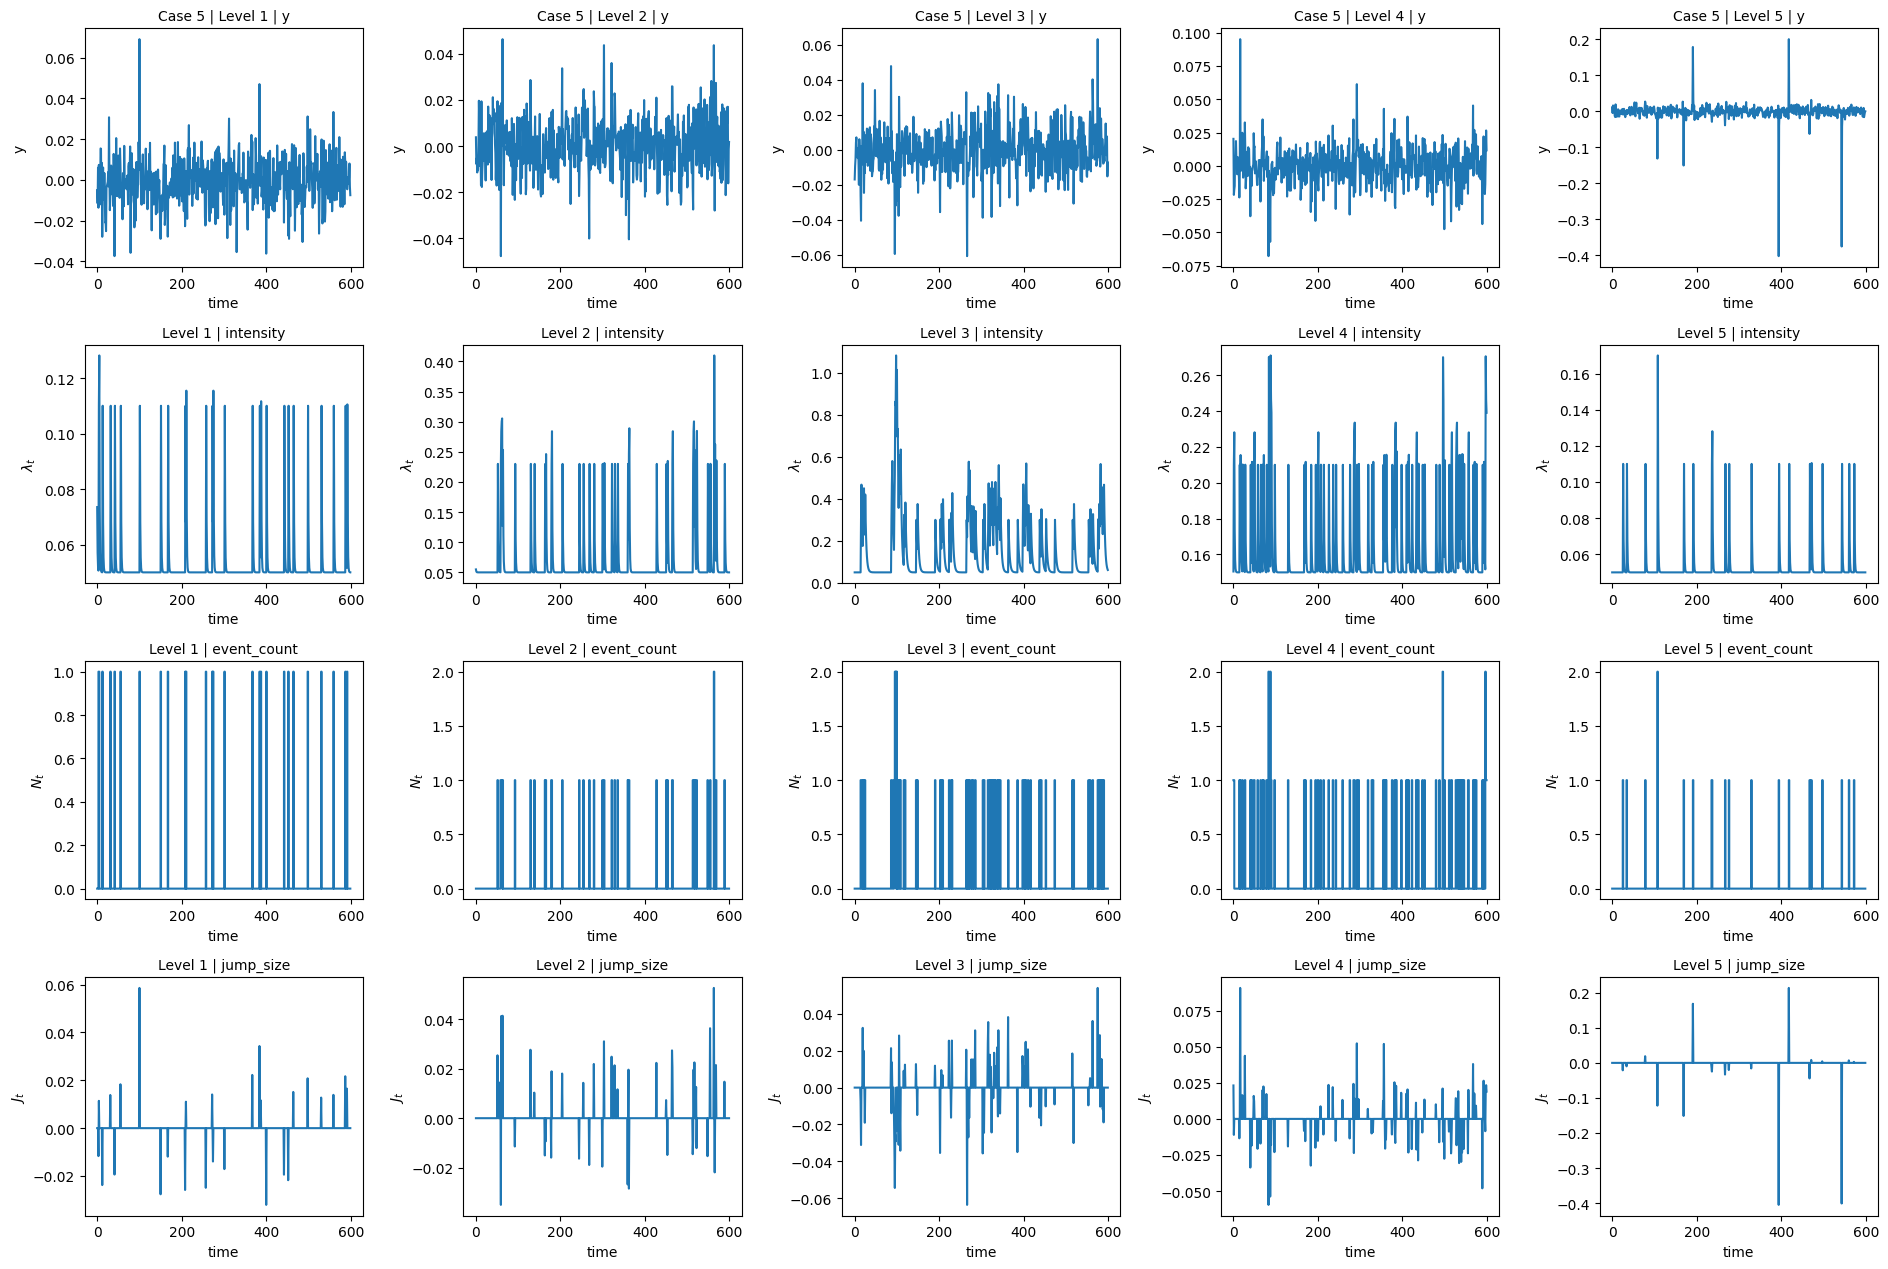

In [24]:
plot_case5_one_series_across_levels(outputs5, T_plot=600, series_id=0)

In [119]:
o = outputs5[0]
print(o["tag"])
print(pd.read_csv(o["csv_path"]).columns.tolist())

case5_hawkes_level01_T2000_N100_seed2026
['time', 'series_id', 'y', 'event_count', 'intensity', 'jump_size']


case 6

In [76]:
# =========================
# Case 6: Zero-inflated jumps (5 difficulty levels)
# FULL code BEFORE "RUN GENERATION"
# =========================

import os
import json
from pathlib import Path
import numpy as np
import pandas as pd

import importlib
import simulators.zero_inflated as zi
importlib.reload(zi)
from simulators.zero_inflated import ZeroInflatedJumpsSimulator  # adjust path if needed


CASE6_LEVELS = [
    dict(level=1, pi=0.30, lam=0.05, jump_mean_abs=0.010, jump_sigma_log=0.25, phi=0.05),
    dict(level=2, pi=0.50, lam=0.10, jump_mean_abs=0.020, jump_sigma_log=0.40, phi=0.10),
    dict(level=3, pi=0.70, lam=0.20, jump_mean_abs=0.030, jump_sigma_log=0.60, phi=0.20),
    dict(level=4, pi=0.85, lam=0.35, jump_mean_abs=0.050, jump_sigma_log=0.80, phi=0.35),
    dict(level=5, pi=0.95, lam=0.60, jump_mean_abs=0.080, jump_sigma_log=1.00, phi=0.50),
]

CASE6_FIXED = dict(
    T=2000,
    mu=0.0,
    sigma_eps=0.01,
    p_up=0.5,
    burn_in=200,
)


def generate_case6_dataset(
    level_cfg: dict,
    fixed_cfg: dict,
    seed: int,
    out_dir: str | Path,
    save_csv: bool = True,
    save_parquet: bool = False,
) -> dict:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    cfg = {**fixed_cfg, **level_cfg}

    sim = ZeroInflatedJumpsSimulator(
        T=cfg["T"],
        mu=cfg["mu"],
        phi=cfg["phi"],
        sigma_eps=cfg["sigma_eps"],
        pi=cfg["pi"],
        lam=cfg["lam"],
        jump_mean_abs=cfg["jump_mean_abs"],
        jump_sigma_log=cfg["jump_sigma_log"],
        p_up=cfg["p_up"],
        burn_in=cfg["burn_in"],
        seed=seed,
    )

    result = sim.simulate()
    df = sim.to_dataframe()  # time, series_id, y, jump_count, jump_size

    tag = (
        f"case6_zip_level{cfg['level']:02d}"
        f"_T{cfg['T']}_seed{seed}"
        f"_pi{cfg['pi']}_lam{cfg['lam']}"
        f"_jm{cfg['jump_mean_abs']}_js{cfg['jump_sigma_log']}_phi{cfg['phi']}"
    )

    csv_path = out_dir / f"{tag}.csv"
    pq_path = out_dir / f"{tag}.parquet"
    meta_path = out_dir / f"{tag}.meta.json"

    if save_csv:
        df.to_csv(csv_path, index=False)
    if save_parquet:
        df.to_parquet(pq_path, index=False)

    meta = {
        "case": "case6_zero_inflated_jumps",
        "tag": tag,
        "seed": seed,
        "tuned_params": {
            "pi": cfg["pi"],
            "lam": cfg["lam"],
            "jump_mean_abs": cfg["jump_mean_abs"],
            "jump_sigma_log": cfg["jump_sigma_log"],
            "phi": cfg["phi"],
        },
        "fixed_params": dict(fixed_cfg),
        "sim_params_dump": result.get("params", {}),
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    summary = {
        "n_rows": int(df.shape[0]),
        "T_effective": int(df["time"].nunique()),
        "mean_y": float(df["y"].mean()),
        "std_y": float(df["y"].std()),
        "p_jump_emp": float((df["jump_count"] > 0).mean()),
        "E_N_emp": float(df["jump_count"].mean()),
        "mean_abs_jump_emp": float(df.loc[df["jump_count"] > 0, "jump_size"].abs().mean())
            if (df["jump_count"] > 0).any() else 0.0,
    }

    return {
        "tag": tag,
        "csv_path": str(csv_path) if save_csv else None,
        "parquet_path": str(pq_path) if save_parquet else None,
        "meta_path": str(meta_path),
        "config": cfg,
        "summary": summary,
    }


def generate_case6_5levels(
    out_dir: str | Path,
    base_seed: int = 2025,
    save_csv: bool = True,
    save_parquet: bool = False,
) -> list[dict]:
    outputs = []
    for level_cfg in CASE6_LEVELS:
        level = level_cfg["level"]
        seed = base_seed + level
        outputs.append(
            generate_case6_dataset(
                level_cfg=level_cfg,
                fixed_cfg=CASE6_FIXED,
                seed=seed,
                out_dir=out_dir,
                save_csv=save_csv,
                save_parquet=save_parquet,
            )
        )
    return outputs


In [77]:
OUT_DIR = "./generated_datasets/case6_zip_5levels"
outputs = generate_case6_5levels(out_dir=OUT_DIR, base_seed=2025, save_csv=True, save_parquet=False)
pd.DataFrame([{"tag": o["tag"], **o["summary"]} for o in outputs])


,tag,n_rows,T_effective,mean_y,std_y,p_jump_emp,E_N_emp,mean_abs_jump_emp
0,case6_zip_level01_T2000_seed2026_pi0.3_lam0.05...,2000,2000,0.000240,0.010297,0.0380,0.0385,0.009874
1,case6_zip_level02_T2000_seed2027_pi0.5_lam0.1_...,2000,2000,0.000508,0.010878,0.0410,0.0455,0.018247
2,case6_zip_level03_T2000_seed2028_pi0.7_lam0.2_...,2000,2000,-0.000151,0.011994,0.0465,0.0515,0.025079
3,case6_zip_level04_T2000_seed2029_pi0.85_lam0.3...,2000,2000,-0.000959,0.021850,0.0530,0.0635,0.052300
4,case6_zip_level05_T2000_seed2030_pi0.95_lam0.6...,2000,2000,-0.002080,0.028830,0.0265,0.0345,0.087357


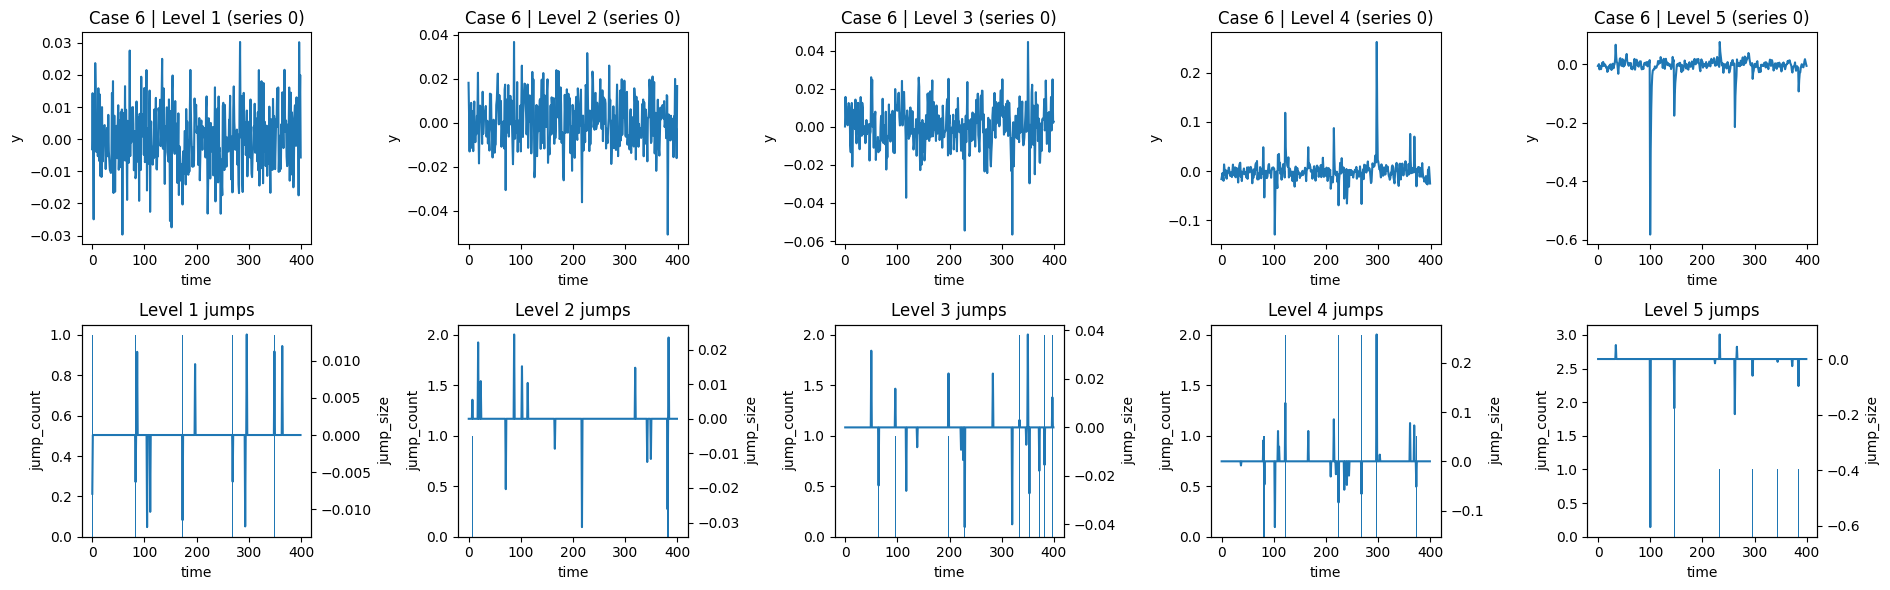

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_case6_one_series_across_levels(
    outputs: list[dict],
    series_id: int = 0,
    T_plot: int = 400,
):
    """
    Case 6: plot y (top row) and jump_count / jump_size (bottom row) across levels.
    Bottom row uses a secondary axis: bars for jump_count, line for jump_size.
    """
    n_levels = len(outputs)
    fig, axes = plt.subplots(
        2, n_levels,
        figsize=(3.8 * n_levels, 6.0),
        sharex=False, sharey=False
    )

    for j, out in enumerate(sorted(outputs, key=lambda x: x["config"]["level"])):
        level = out["config"]["level"]
        df = pd.read_csv(out["csv_path"])
        s = df[df["series_id"] == series_id].sort_values("time").head(T_plot)

        # --- Top: y ---
        ax = axes[0, j]
        ax.plot(s["time"].values, s["y"].values)
        ax.set_title(f"Case 6 | Level {level} (series {series_id})")
        ax.set_xlabel("time")
        ax.set_ylabel("y")

        # --- Bottom: jumps ---
        axb = axes[1, j]
        axb.bar(s["time"].values, s["jump_count"].values)
        axb.set_xlabel("time")
        axb.set_ylabel("jump_count")

        axb2 = axb.twinx()
        axb2.plot(s["time"].values, s["jump_size"].values)
        axb2.set_ylabel("jump_size")

        axb.set_title(f"Level {level} jumps")

    plt.tight_layout()
    plt.show()


plot_case6_one_series_across_levels(outputs, series_id=0, T_plot=400)


In [25]:
# =========================
# Case 6 (Option A): Market-wide ZIP jumps + panel observation
# FULL code BEFORE "RUN GENERATION"
# =========================

import json
from pathlib import Path
import numpy as np
import pandas as pd
import importlib
import simulators.zero_inflated as zi
importlib.reload(zi)

# IMPORTANT: use the Option A panel simulator class name you implemented
# from ts_synth.simulators.zero_inflated import MarketZIPPanelSimulator
from simulators.zero_inflated import MarketZIPPanelSimulator

# -------------------------------------------------------
# 5 difficulty levels (easy -> hard)
# -------------------------------------------------------
# Interpretation:
#  - pi: structural zeros (higher pi => fewer jump times; more "burstiness")
#  - lam: Poisson rate when "active" (higher lam => more events per active time)
#  - jump_mean_abs: mean absolute jump magnitude per event
#  - jump_sigma_log: tail/heaviness of magnitudes
#  - phi: AR memory (higher => more persistence / harder separation)
#
# NOTE: For ZIP, the overall jump probability is:
#   P(N_t > 0) = (1 - pi) * (1 - exp(-lam))
# You may want monotone difficulty in both jump frequency AND jump size;
# current schedule does that in a "harder as you go" sense.
# -------------------------------------------------------

# -------------------------------------------------------
# Case 6: Zero-inflated market jumps + panel exposure
# 5 DIAGNOSTIC settings (not "easy -> hard")
#
# Key identity for jump timing:
#   P(N_t > 0) = (1 - pi) * (1 - exp(-lam))
# We design levels to isolate:
#   (A) sparsity (pi), (B) active intensity (lam),
#   (C) jump magnitude/tails (jump_mean_abs, jump_sigma_log),
#   (D) AR persistence (phi)
# -------------------------------------------------------

CASE6_LEVELS = [
    # Level 1: Baseline (balanced)
    dict(level=1, pi=0.70, lam=0.20, jump_mean_abs=0.030, jump_sigma_log=0.60, phi=0.20),
    # Level 2: High sparsity (more structural zeros) — isolate pi
    dict(level=2, pi=0.90, lam=0.20, jump_mean_abs=0.030, jump_sigma_log=0.60, phi=0.20),
    # Level 3: Bursty active periods (higher Poisson rate when active) — isolate lam
    dict(level=3, pi=0.70, lam=0.60, jump_mean_abs=0.030, jump_sigma_log=0.60, phi=0.20),
    # Level 4: Heavy-tailed / larger jumps — isolate magnitude distribution
    dict(level=4, pi=0.70, lam=0.20, jump_mean_abs=0.080, jump_sigma_log=1.00, phi=0.20),
    # Level 5: High AR persistence (harder diffusive vs jump separation) — isolate phi
    dict(level=5, pi=0.70, lam=0.20, jump_mean_abs=0.030, jump_sigma_log=0.60, phi=0.55),
]

# -------------------------------------------------------
# Fixed parameters (constant across levels)
# -------------------------------------------------------
CASE6_FIXED = dict(
    T=20000,
    burn_in=200,
    n_firms=50,       # keep fixed for the paper (recommended)
    n_factors=0,       # Case 6 story is "market jump + AR"; set >0 only if you want factors too
    sigma_eps=0.01,
    mu=0.0,            # if you include a drift term in your simulator; otherwise remove
    p_up=0.5,
    # exposure distribution (firm sensitivity to market jump)
    gamma_mean=1.0,
    gamma_std=0.2,
    # cross-sectional intercepts (optional)
    alpha_i_std=0.001,
)

def _json_safe(x):
    if isinstance(x, (np.ndarray,)):
        return x.tolist()
    return x

def generate_case6_dataset(
    level_cfg: dict,
    fixed_cfg: dict,
    seed: int,
    out_dir: str | Path,
    save_csv: bool = True,
    save_parquet: bool = False,
) -> dict:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    cfg = {**fixed_cfg, **level_cfg}

    sim = MarketZIPPanelSimulator(
        T=cfg["T"],
        n_firms=cfg["n_firms"],
        n_factors=cfg["n_factors"],
        phi=cfg["phi"],
        sigma_eps=cfg["sigma_eps"],

        pi=cfg["pi"],
        lam=cfg["lam"],
        jump_mean_abs=cfg["jump_mean_abs"],
        jump_sigma_log=cfg["jump_sigma_log"],
        p_up=cfg["p_up"],

        gamma_mean=cfg["gamma_mean"],
        gamma_std=cfg["gamma_std"],

        alpha_i_std=cfg["alpha_i_std"],

        burn_in=cfg["burn_in"],
        seed=seed,
    )

    result = sim.simulate()
    df = sim.to_dataframe().copy()

    # sanity: enforce tidy schema expectations
    required_cols = {"time", "series_id", "y", "jump_count", "jump_size"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Case6 OptionA: missing required columns {missing}. Got: {list(df.columns)}")

    # Tag / paths
    tag = (
        f"case6_zip_panel_level{cfg['level']:02d}"
        f"_N{cfg['n_firms']}_T{cfg['T']}_seed{seed}"
        f"_pi{cfg['pi']}_lam{cfg['lam']}"
        f"_jm{cfg['jump_mean_abs']}_js{cfg['jump_sigma_log']}_phi{cfg['phi']}"
    )

    csv_path = out_dir / f"{tag}.csv"
    pq_path = out_dir / f"{tag}.parquet"
    meta_path = out_dir / f"{tag}.meta.json"

    if save_csv:
        df.to_csv(csv_path, index=False)
    if save_parquet:
        df.to_parquet(pq_path, index=False)

    # ---- Metadata
    tuned = {
        "pi": cfg["pi"],
        "lam": cfg["lam"],
        "jump_mean_abs": cfg["jump_mean_abs"],
        "jump_sigma_log": cfg["jump_sigma_log"],
        "phi": cfg["phi"],
    }
    fixed_dump = dict(fixed_cfg)

    meta = {
        "case": "case6_zero_inflated_jumps_optionA_panel",
        "tag": tag,
        "seed": seed,
        "tuned_params": tuned,
        "fixed_params": fixed_dump,
        "sim_params_dump": {k: _json_safe(v) for k, v in result.get("params", {}).items()},
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    # ---- Summaries (panel-aware)
    # overall jump time indicator (shared across firms, but repeated in tidy df)
    # take unique by time to avoid counting N times
    jump_by_time = (
        df[["time", "jump_count", "jump_size"]]
        .drop_duplicates(subset=["time"])
        .sort_values("time")
        .reset_index(drop=True)
    )

    p_jump_emp = float((jump_by_time["jump_count"] > 0).mean())
    EN_emp = float(jump_by_time["jump_count"].mean())
    mean_abs_J_emp = float(jump_by_time.loc[jump_by_time["jump_count"] > 0, "jump_size"].abs().mean()) \
        if (jump_by_time["jump_count"] > 0).any() else 0.0

    summary = {
        "n_rows": int(df.shape[0]),
        "n_series": int(df["series_id"].nunique()),
        "T_effective": int(df["time"].nunique()),
        "mean_y": float(df["y"].mean()),
        "std_y": float(df["y"].std()),
        # jump stats at the market-time level
        "p_jump_emp_time": p_jump_emp,
        "E_jump_count_emp_time": EN_emp,
        "mean_abs_jump_emp_time": mean_abs_J_emp,
        # exposure sanity (if present)
        "gamma_mean_emp": float(df["gamma"].drop_duplicates().mean()) if "gamma" in df.columns else float("nan"),
        "gamma_std_emp": float(df["gamma"].drop_duplicates().std()) if "gamma" in df.columns else float("nan"),
    }

    return {
        "tag": tag,
        "csv_path": str(csv_path) if save_csv else None,
        "parquet_path": str(pq_path) if save_parquet else None,
        "meta_path": str(meta_path),
        "config": cfg,
        "summary": summary,
    }


def generate_case6_5levels(
    out_dir: str | Path,
    base_seed: int = 2025,
    save_csv: bool = True,
    save_parquet: bool = False,
) -> list[dict]:
    outputs = []
    for level_cfg in CASE6_LEVELS:
        level = int(level_cfg["level"])
        seed = base_seed + level
        outputs.append(
            generate_case6_dataset(
                level_cfg=level_cfg,
                fixed_cfg=CASE6_FIXED,
                seed=seed,
                out_dir=out_dir,
                save_csv=save_csv,
                save_parquet=save_parquet,
            )
        )
    return outputs

In [26]:
OUT_DIR = "./generated_datasets_T20000/case6_zip_5levels"
outputs = generate_case6_5levels(out_dir=OUT_DIR, base_seed=2025, save_csv=True, save_parquet=False)
pd.DataFrame([{"tag": o["tag"], **o["summary"]} for o in outputs])

,tag,n_rows,n_series,T_effective,mean_y,std_y,p_jump_emp_time,E_jump_count_emp_time,mean_abs_jump_emp_time,gamma_mean_emp,gamma_std_emp
0,case6_zip_panel_level01_N50_T20000_seed2026_pi...,1000000,50,20000,0.000158,0.013573,0.05285,0.05835,0.030991,0.978531,0.182314
1,case6_zip_panel_level02_N50_T20000_seed2027_pi...,1000000,50,20000,-0.000020,0.011513,0.01720,0.01975,0.031224,1.003041,0.224001
2,case6_zip_panel_level03_N50_T20000_seed2028_pi...,1000000,50,20000,0.000370,0.019031,0.13730,0.18435,0.033486,0.983496,0.208314
3,case6_zip_panel_level04_N50_T20000_seed2029_pi...,1000000,50,20000,-0.000103,0.034852,0.05440,0.06000,0.084921,1.021189,0.241408
4,case6_zip_panel_level05_N50_T20000_seed2030_pi...,1000000,50,20000,-0.000404,0.016297,0.05700,0.06280,0.030840,1.015706,0.192791


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_case6_one_series_across_levels(
    outputs: list[dict],
    T_plot: int = 600,
    series_id: int = 0,
):
    """
    Visualize Case 6 (Zero-inflated jumps / ZIP) across 5 difficulty levels.

    Assumes each `out` in outputs contains either:
      - out["df"] as a DataFrame, OR
      - out["csv_path"] pointing to a saved CSV, OR
      - out["sim"] (optional) and you can call sim.to_dataframe()

    Expected columns in the dataframe:
      time, series_id, y, jump_count, jump_size
    (extra columns are fine)

    Layout (3 x n_levels):
      Row 1: y_t
      Row 2: jump_count N_t (step plot)
      Row 3: jump_size J_t
    """
    outs = sorted(outputs, key=lambda x: x["config"]["level"])
    n_levels = len(outs)

    fig, axes = plt.subplots(
        3, n_levels,
        figsize=(3.8 * n_levels, 3.0 * 3),
        sharex=False, sharey=False
    )

    # If n_levels == 1, matplotlib returns 1D arrays; normalize to 2D indexing
    if n_levels == 1:
        axes = np.array(axes).reshape(3, 1)

    def _load_df(out: dict) -> pd.DataFrame:
        if "df" in out and isinstance(out["df"], pd.DataFrame):
            return out["df"].copy()
        if out.get("csv_path"):
            return pd.read_csv(out["csv_path"])
        if "sim" in out:
            return out["sim"].to_dataframe()
        raise KeyError("Each output must contain either 'df', 'csv_path', or 'sim'.")

    def _ensure_cols(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        rename_map = {}
        if "firm_id" in df.columns and "series_id" not in df.columns:
            rename_map["firm_id"] = "series_id"
        if "return" in df.columns and "y" not in df.columns:
            rename_map["return"] = "y"
        if rename_map:
            df = df.rename(columns=rename_map)

        required = {"time", "series_id", "y"}
        missing = required - set(df.columns)
        if missing:
            raise KeyError(f"Missing required columns {missing}. Found columns: {list(df.columns)}")

        # Case 6 expected extras:
        if "jump_count" not in df.columns:
            raise KeyError(f"Missing 'jump_count'. Found columns: {list(df.columns)}")
        if "jump_size" not in df.columns:
            raise KeyError(f"Missing 'jump_size'. Found columns: {list(df.columns)}")

        return df

    for j, out in enumerate(outs):
        level = out["config"]["level"]

        df = _ensure_cols(_load_df(out))
        df = df[df["series_id"] == series_id].sort_values("time").head(T_plot)

        # Row 1: y
        axes[0, j].plot(df["time"], df["y"])
        axes[0, j].set_title(f"Case 6 | Level {level} | series {series_id} | y")
        axes[0, j].set_xlabel("time")
        axes[0, j].set_ylabel("y")

        # Row 2: jump_count
        axes[1, j].step(df["time"], df["jump_count"], where="post")
        axes[1, j].set_title(f"Case 6 | Level {level} | series {series_id} | jump_count")
        axes[1, j].set_xlabel("time")
        axes[1, j].set_ylabel(r"$N_t$")

        # Row 3: jump_size
        axes[2, j].plot(df["time"], df["jump_size"])
        axes[2, j].set_title(f"Case 6 | Level {level} | series {series_id} | jump_size")
        axes[2, j].set_xlabel("time")
        axes[2, j].set_ylabel(r"$J_t$")

        # Optional: small annotation for empirical jump probability in the plotted window
        p_jump = float((df["jump_count"] > 0).mean()) if len(df) else float("nan")
        axes[2, j].text(
            0.02, 0.95,
            f"p(jump>0)≈{p_jump:.3f}",
            transform=axes[2, j].transAxes,
            va="top"
        )

    plt.tight_layout()
    plt.show()

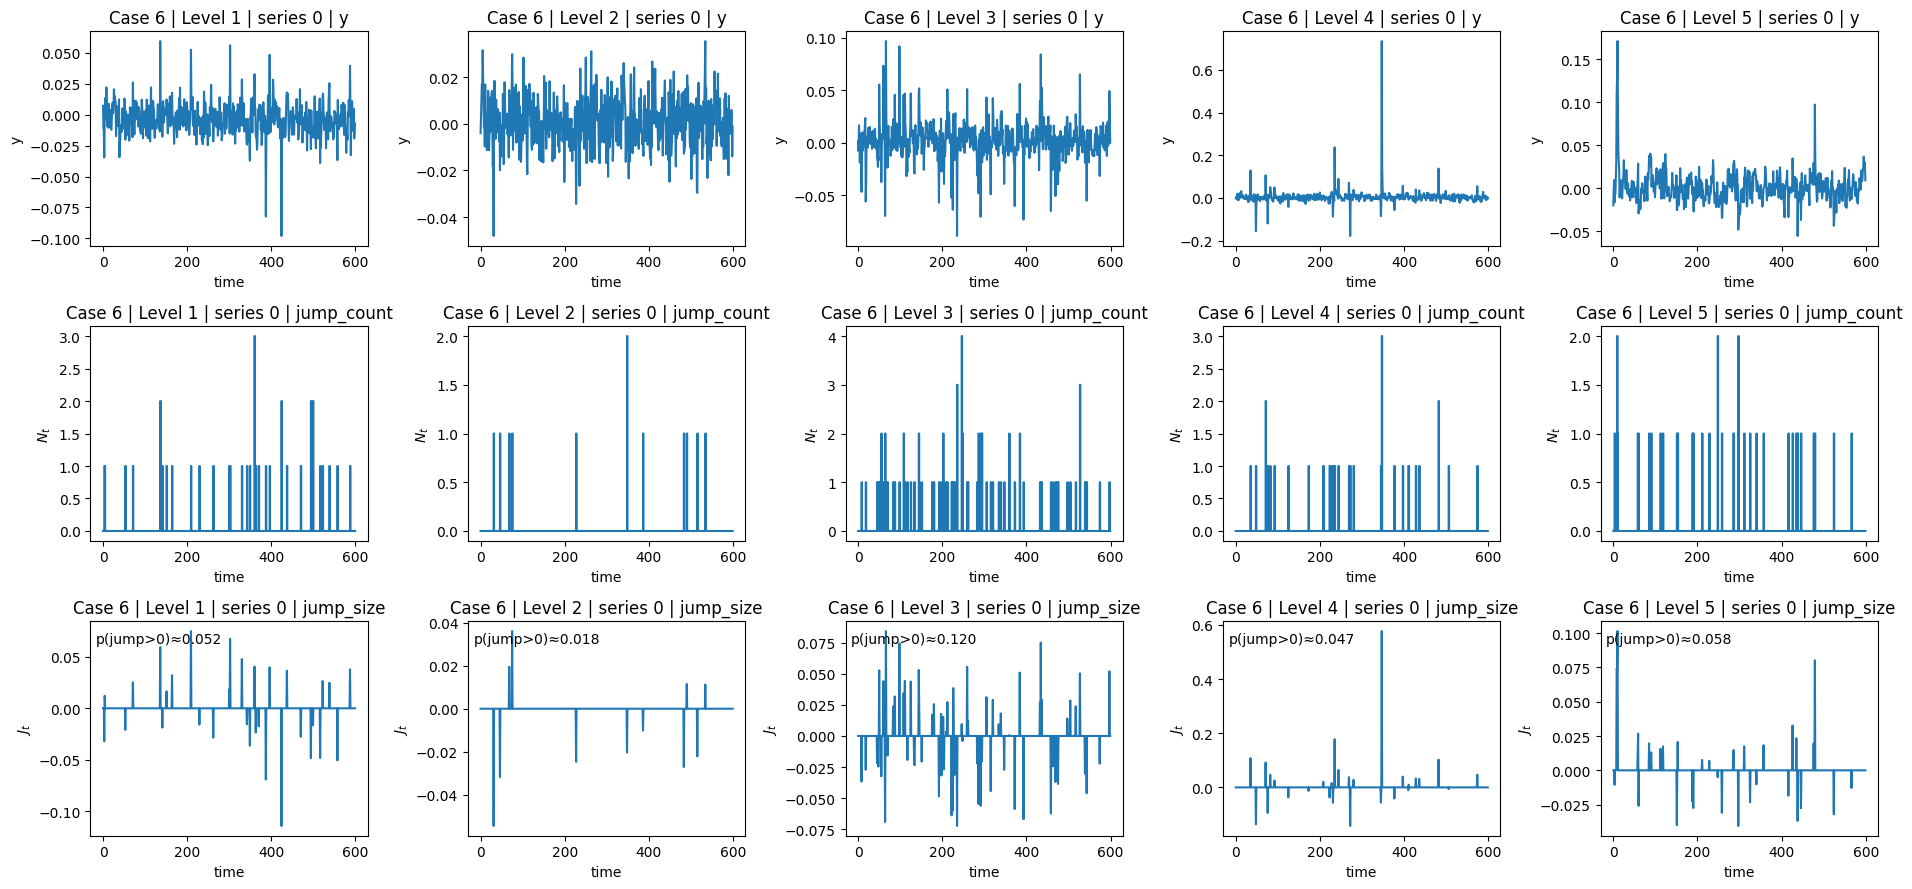

In [28]:
plot_case6_one_series_across_levels(outputs, T_plot=600, series_id=0)

In [29]:
import os
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd


# ----------------------------
# Helpers: format detection
# ----------------------------
def _detect_format(df: pd.DataFrame) -> str:
    """
    Returns: 'tidy' if looks like long format with time/series_id/y,
             'wide' if looks like wide matrix with time index and series columns,
             'unknown' otherwise.
    """
    cols = set(df.columns.str.lower())
    if {"time", "series_id", "y"}.issubset(cols):
        return "tidy"
    # wide heuristic: first col might be time; others numeric
    if "time" in cols and df.shape[1] > 2:
        return "wide"
    # another wide heuristic: no series_id, many numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) >= 10 and "series_id" not in cols and "y" not in cols:
        return "wide"
    return "unknown"


def _coerce_lower_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    return df


def _infer_case_from_path(path: Path) -> Optional[int]:
    m = re.search(r"case(\d+)", str(path).lower())
    return int(m.group(1)) if m else None


# ----------------------------
# Core checks
# ----------------------------
def check_dataset_file(
    csv_path: Path,
    expected_n_series: int = 50,
    expected_min_T: int = 100,
    require_cols: Optional[List[str]] = None,
) -> Dict[str, Any]:
    """
    Checks one CSV file. Returns a dict with summary stats + issues/warnings.
    """
    out: Dict[str, Any] = {
        "file": str(csv_path),
        "ok": True,
        "format": None,
        "n_rows": None,
        "n_cols": None,
        "n_series": None,
        "T_per_series_min": None,
        "T_per_series_max": None,
        "time_min": None,
        "time_max": None,
        "y_mean": None,
        "y_std": None,
        "issues": [],
        "warnings": [],
    }

    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        out["ok"] = False
        out["issues"].append(f"Failed to read CSV: {e}")
        return out

    df = _coerce_lower_cols(df)
    out["n_rows"], out["n_cols"] = df.shape

    fmt = _detect_format(df)
    out["format"] = fmt

    # Required columns check (if provided)
    if require_cols is not None:
        missing = [c for c in require_cols if c not in df.columns]
        if missing:
            out["ok"] = False
            out["issues"].append(f"Missing required columns: {missing}")

    if fmt == "tidy":
        # normalize col names
        # allow Time / series_id / y with different cases already normalized
        # Ensure dtypes
        for c in ["time", "series_id", "y"]:
            if c not in df.columns:
                out["ok"] = False
                out["issues"].append(f"Expected tidy columns time/series_id/y but missing {c}")
                return out

        # basic numeric sanity
        if not np.issubdtype(df["time"].dtype, np.number):
            out["issues"].append("Column 'time' is not numeric.")
            out["ok"] = False
        if not np.issubdtype(df["series_id"].dtype, np.number):
            # allow series_id as string but then we count unique
            out["warnings"].append("Column 'series_id' is not numeric; treating as categorical.")
        if not np.issubdtype(df["y"].dtype, np.number):
            out["issues"].append("Column 'y' is not numeric.")
            out["ok"] = False
            return out

        # finite y
        if not np.isfinite(df["y"].to_numpy()).all():
            out["issues"].append("Found non-finite values in y (NaN/inf).")
            out["ok"] = False

        # series count
        n_series = df["series_id"].nunique(dropna=False)
        out["n_series"] = int(n_series)
        if expected_n_series is not None and n_series != expected_n_series:
            out["issues"].append(f"Expected {expected_n_series} series, found {n_series}.")
            out["ok"] = False

        # time range and per-series coverage
        out["time_min"] = float(np.nanmin(df["time"].to_numpy()))
        out["time_max"] = float(np.nanmax(df["time"].to_numpy()))

        # per-series lengths
        lens = df.groupby("series_id")["time"].count()
        out["T_per_series_min"] = int(lens.min())
        out["T_per_series_max"] = int(lens.max())
        if out["T_per_series_min"] < expected_min_T:
            out["warnings"].append(f"Very short series detected (min length {out['T_per_series_min']}).")

        if out["T_per_series_min"] != out["T_per_series_max"]:
            out["issues"].append(
                f"Inconsistent time lengths across series: min={out['T_per_series_min']} max={out['T_per_series_max']}."
            )
            out["ok"] = False

        # check contiguous time for each series (strong check but helpful)
        # assumes time is integer-ish
        contig_fail = 0
        for sid, g in df.groupby("series_id"):
            tvals = np.sort(g["time"].to_numpy())
            # check unique
            if len(np.unique(tvals)) != len(tvals):
                contig_fail += 1
                continue
            diffs = np.diff(tvals)
            if not np.all(diffs == diffs[0]) or diffs[0] <= 0:
                # allow constant step but not necessarily 1
                contig_fail += 1
                continue
        if contig_fail > 0:
            out["warnings"].append(f"{contig_fail}/{n_series} series have non-contiguous or irregular time steps.")

        # y distribution sanity
        out["y_mean"] = float(df["y"].mean())
        out["y_std"] = float(df["y"].std(ddof=1))
        if out["y_std"] == 0.0:
            out["issues"].append("y has zero variance (constant series).")
            out["ok"] = False

        # Check for huge duplicates of common diagnostics (optional):
        # e.g. in Case5/6, event_count/intensity/jump_size should be identical across series at same time
        common_cols = [c for c in ["event_count", "intensity", "jump_size", "jump_count"] if c in df.columns]
        for c in common_cols:
            # check that within each time, values are identical across series
            nunique_by_time = df.groupby("time")[c].nunique(dropna=False)
            if (nunique_by_time > 1).any():
                out["warnings"].append(f"Column '{c}' varies across series within the same time (expected common).")

    elif fmt == "wide":
        # Try to interpret: one row per time, columns per series
        # If 'time' exists, treat others as series columns; else treat all numeric columns as series.
        cols_lower = [c.lower() for c in df.columns]
        if "time" in cols_lower:
            time_col = df.columns[cols_lower.index("time")]
            series_cols = [c for c in df.columns if c != time_col]
            time_vals = df[time_col].to_numpy()
            out["time_min"] = float(np.nanmin(time_vals))
            out["time_max"] = float(np.nanmax(time_vals))
        else:
            time_col = None
            series_cols = list(df.columns)

        # keep only numeric series cols
        numeric_series_cols = [c for c in series_cols if np.issubdtype(df[c].dtype, np.number)]
        out["n_series"] = int(len(numeric_series_cols))
        if expected_n_series is not None and out["n_series"] != expected_n_series:
            out["issues"].append(f"Expected {expected_n_series} series cols, found {out['n_series']} numeric series cols.")
            out["ok"] = False

        T = df.shape[0]
        out["T_per_series_min"] = int(T)
        out["T_per_series_max"] = int(T)
        if T < expected_min_T:
            out["warnings"].append(f"Very short dataset detected (T={T}).")

        # y stats: flatten numeric values
        vals = df[numeric_series_cols].to_numpy().reshape(-1)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            out["issues"].append("No finite numeric values found in wide series columns.")
            out["ok"] = False
        else:
            out["y_mean"] = float(np.mean(vals))
            out["y_std"] = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            if out["y_std"] == 0.0:
                out["issues"].append("y has zero variance (all constant).")
                out["ok"] = False

    else:
        out["ok"] = False
        out["issues"].append("Unrecognized dataset format (neither tidy nor wide).")

    return out


def check_generated_datasets(
    root_dir: str = "generated_datasets",
    expected_n_series: int = 50,
    expected_min_T: int = 1500,
    print_top_k_issues: int = 30,
) -> pd.DataFrame:
    """
    Walks all CSV files under root_dir, runs checks, returns summary DataFrame.
    """
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Folder not found: {root.resolve()}")

    csv_files = sorted(root.rglob("*.csv"))
    if len(csv_files) == 0:
        raise FileNotFoundError(f"No CSV files found under: {root.resolve()}")

    results: List[Dict[str, Any]] = []
    for fp in csv_files:
        results.append(
            check_dataset_file(
                fp,
                expected_n_series=expected_n_series,
                expected_min_T=expected_min_T,
            )
        )

    df = pd.DataFrame(results)

    # Print a quick report
    n_total = len(df)
    n_ok = int(df["ok"].sum())
    n_bad = n_total - n_ok
    print(f"Checked {n_total} CSV files under {root.resolve()}")
    print(f"OK: {n_ok} | Issues: {n_bad}")

    # Show top issues
    bad = df[~df["ok"]].copy()
    if len(bad) > 0:
        print("\n--- Files with issues (showing up to top_k) ---")
        for i, row in bad.head(print_top_k_issues).iterrows():
            print(f"\n{row['file']}")
            for msg in row["issues"]:
                print(f"  [ISSUE] {msg}")
            for msg in row["warnings"]:
                print(f"  [WARN ] {msg}")

    # Also show warnings for OK files (optional)
    warn = df[df["ok"] & df["warnings"].apply(lambda x: len(x) > 0)]
    if len(warn) > 0:
        print(f"\n--- OK files with warnings: {len(warn)}/{n_ok} ---")

    return df


# ----------------------------
# Convenience: per-folder summary
# ----------------------------
def summarize_by_case_level(summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds a 'case_folder' column and summarizes pass rates per folder.
    """
    tmp = summary_df.copy()
    tmp["case_folder"] = tmp["file"].apply(lambda x: str(Path(x).parent.name))
    g = tmp.groupby("case_folder").agg(
        n_files=("file", "count"),
        n_ok=("ok", "sum"),
        ok_rate=("ok", "mean"),
        n_warn=("warnings", lambda s: int(np.sum([len(x) > 0 for x in s]))),
    ).reset_index()
    g["ok_rate"] = g["ok_rate"].round(3)
    return g


# ----------------------------
# RUN IT (typical usage)
# ----------------------------
# summary = check_generated_datasets(
#     root_dir="generated_datasets",
#     expected_n_series=50,
#     expected_min_T=1800,  # adjust if your T=2000 and burn-in removed etc.
# )
# display(summary.head())
# display(summarize_by_case_level(summary))


In [31]:
summary = check_generated_datasets(
    root_dir="generated_datasets_T20000",
    expected_n_series=50,
    expected_min_T=20000,  # set based on your saved T after burn-in
)
summary_by_folder = summarize_by_case_level(summary)
summary_by_folder


Checked 30 CSV files under C:\Users\Sun Jiaze\PycharmProjects\ts_synth\ts_synth\generated_datasets_T20000
OK: 30 | Issues: 0


,case_folder,n_files,n_ok,ok_rate,n_warn
0,case1_garch_5levels,5,5,1.0,0
1,case2_har_5levels,5,5,1.0,0
2,case3_heavytail_5levels,5,5,1.0,0
3,case4_regime_5levels,5,5,1.0,0
4,case5_hawkes_5levels,5,5,1.0,0
5,case6_zip_5levels,5,5,1.0,0
